<a href="https://colab.research.google.com/github/reubyTuesday/Math509RealEstate/blob/main/Boston_Dataset_MATH509_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# MATH 509 Project - Boston Dataset - Regression Approaches.
%pylab inline
%config InlineBackend.figure_format = 'retina'
from ipywidgets import interact
import scipy.stats as stats
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_openml


Populating the interactive namespace from numpy and matplotlib


# Load data from the source

In [2]:
# Define the path to the dataset
path_to_data = 'https://drive.google.com/uc?id=1hWB66jk3g37_Qq53UHx_lDG2iIQCmNkQ'

# Read the dataset without assuming a header
data = pd.read_csv(path_to_data, delim_whitespace=True, header=None)

# Define column names (ensure they match the dataset)
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
                'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

# Assign column names to the DataFrame
data.columns = column_names

# Delete the 'B' column
data = data.drop('B', axis=1)

# Display the entire dataset
# print(data)

<ipython-input-2-3e2bfc7f4e64>:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(path_to_data, delim_whitespace=True, header=None)


# Creating Scatter plot

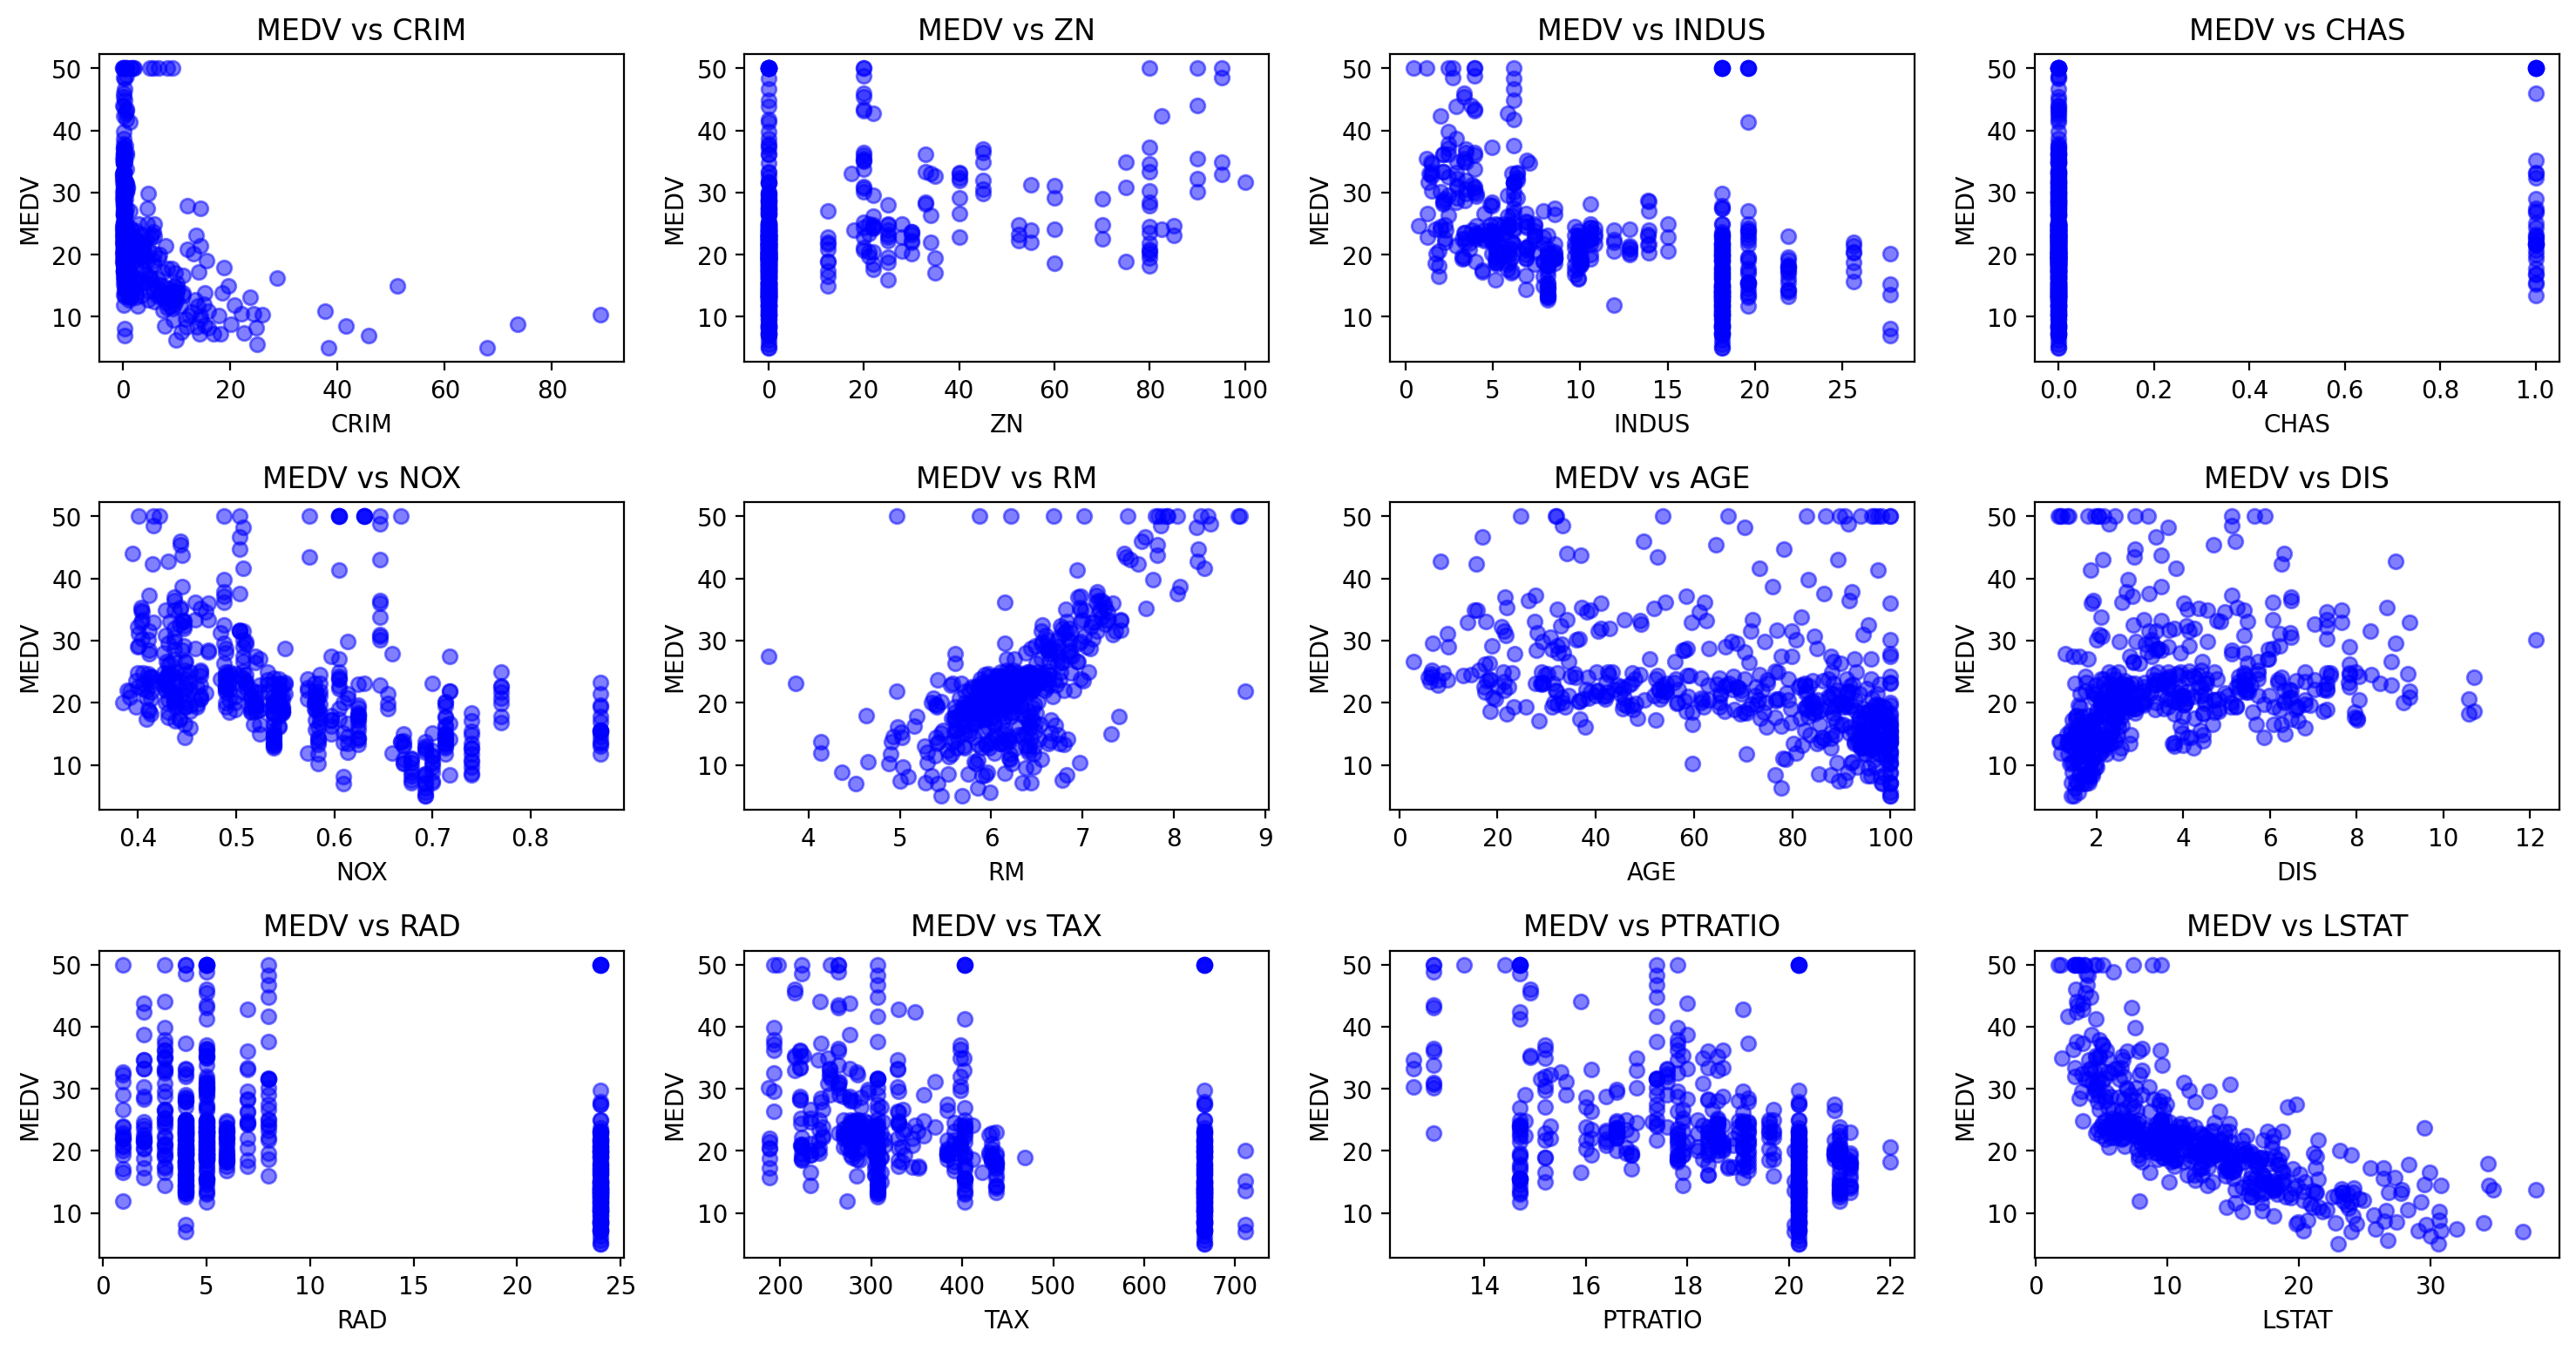

In [3]:
# Creating scatter plots

# Define the response variable (target)
y_response = data['MEDV']

# Create scatter plots for each predictor against the target variable
plt.figure(figsize=(15, 10))  # Set figure size

for i, col in enumerate(data.columns[:-1]):  # Exclude MEDV from predictors
    plt.subplot(4, 4, i + 1)  # Create subplots in a 4x4 grid
    plt.scatter(data[col], y_response, color='blue', alpha=0.5)  # Set blue color
    plt.xlabel(col)
    plt.ylabel('MEDV')
    plt.title(f'MEDV vs {col}')

plt.tight_layout()  # Adjust layout for better spacing
plt.show()


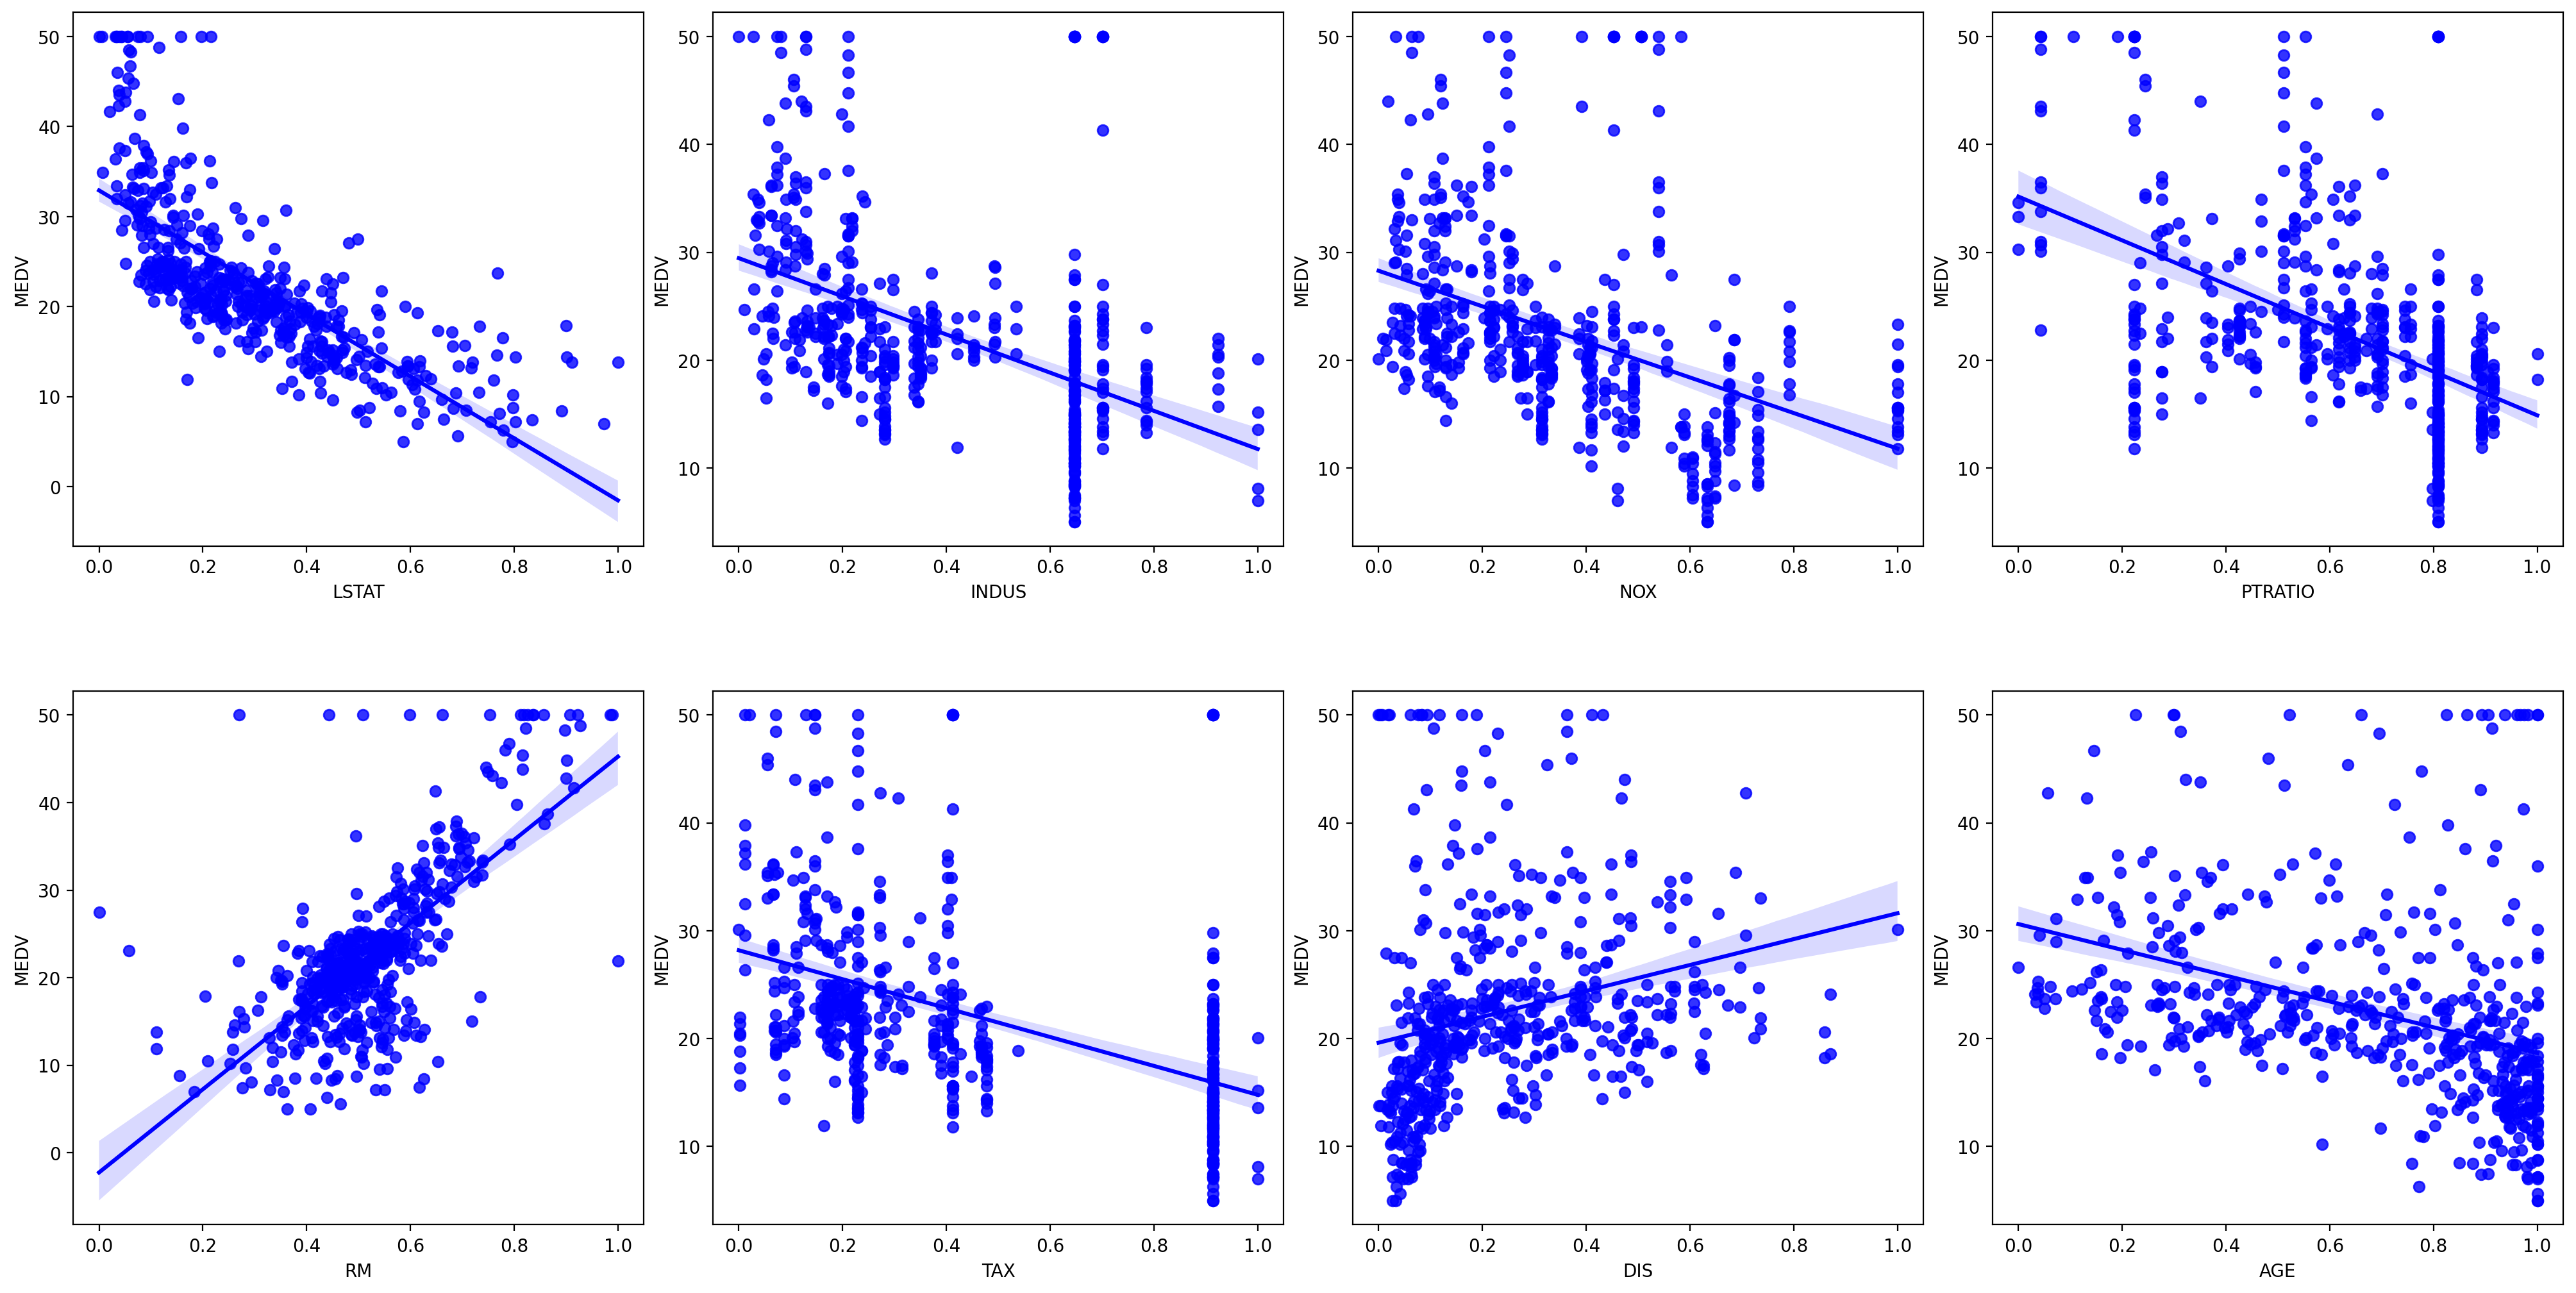

In [4]:
from sklearn import preprocessing
import seaborn as sns # import seaborn here as well.
# Let's scale the columns before plotting them against MEDV
min_max_scaler = preprocessing.MinMaxScaler()
column_sels = ['LSTAT', 'INDUS', 'NOX', 'PTRATIO', 'RM', 'TAX', 'DIS', 'AGE']
x = data.loc[:,column_sels]
y = data['MEDV']
x = pd.DataFrame(data=min_max_scaler.fit_transform(x), columns=column_sels)
fig, axs = plt.subplots(ncols=4, nrows=2, figsize=(20, 10))
index = 0
axs = axs.flatten()
for i, k in enumerate(column_sels):
    sns.regplot(y=y, x=x[k], ax=axs[i], color='blue')
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

# Crate Boxplot to investigate if there are outliers.

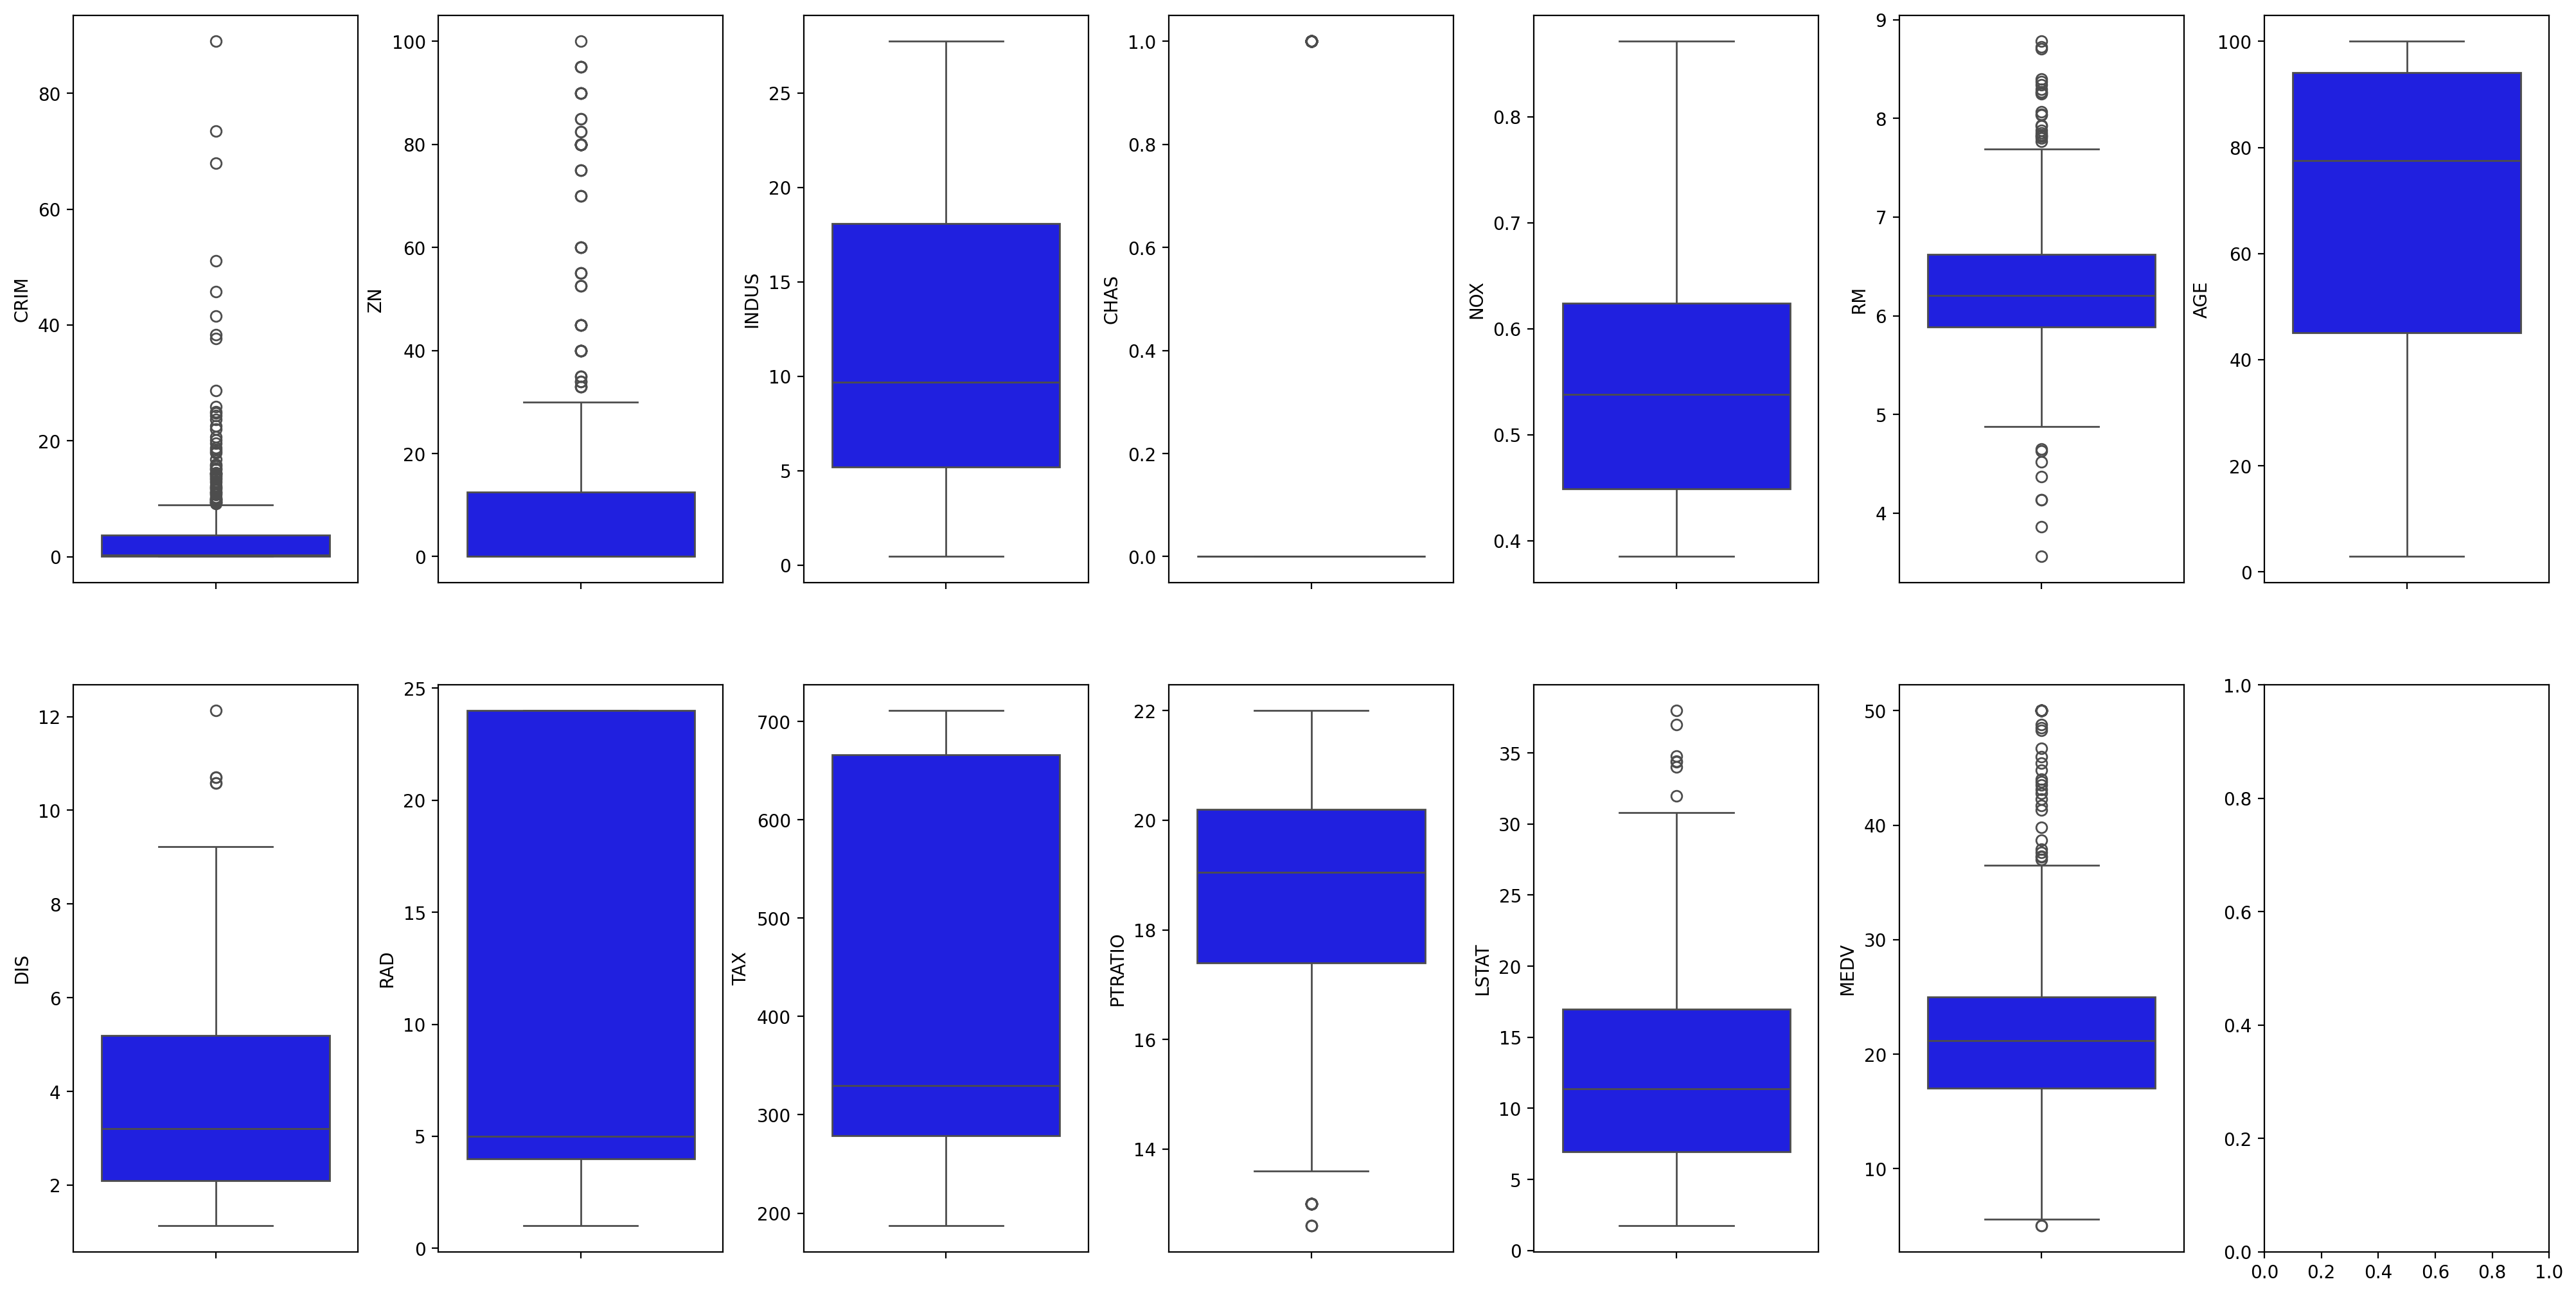

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
index = 0
axs = axs.flatten()
for k,v in data.items():
    sns.boxplot(y=k, data=data, ax=axs[index], color='blue')
    index += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)


In [6]:
data.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


# Applying mean imputation to polish the outliers

In [7]:
# Compute 95th percentile threshold
threshold1 = data['CRIM'].quantile(0.95)

# Replace values greater than the 95th percentile with the threshold value
data.loc[data['CRIM'] > threshold1, 'CRIM'] = data.loc[data['CRIM'] <=threshold1, 'CRIM'].mean()

# Compute 95th percentile threshold
threshold2 = data['ZN'].quantile(0.85)

# Replace values greater than the 95th percentile with the threshold value
data.loc[data['ZN'] > threshold2, 'ZN'] = data.loc[data['ZN'] <=threshold2, 'ZN'].mean()

# Compute 95th percentile threshold
threshold3 = data['MEDV'].quantile(0.95)

# Replace values greater than the 95th percentile with the threshold value
data.loc[data['MEDV'] > threshold3, 'MEDV'] = data.loc[data['MEDV'] <=threshold3, 'MEDV'].mean()

display(data.describe())

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,2.092157,2.820602,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,21.128750
std,3.553630,6.654388,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,6.917394
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.128750
75%,2.092157,2.820602,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,24.100000
max,15.575700,28.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,43.100000


# Creating Boxplot after mean imputation

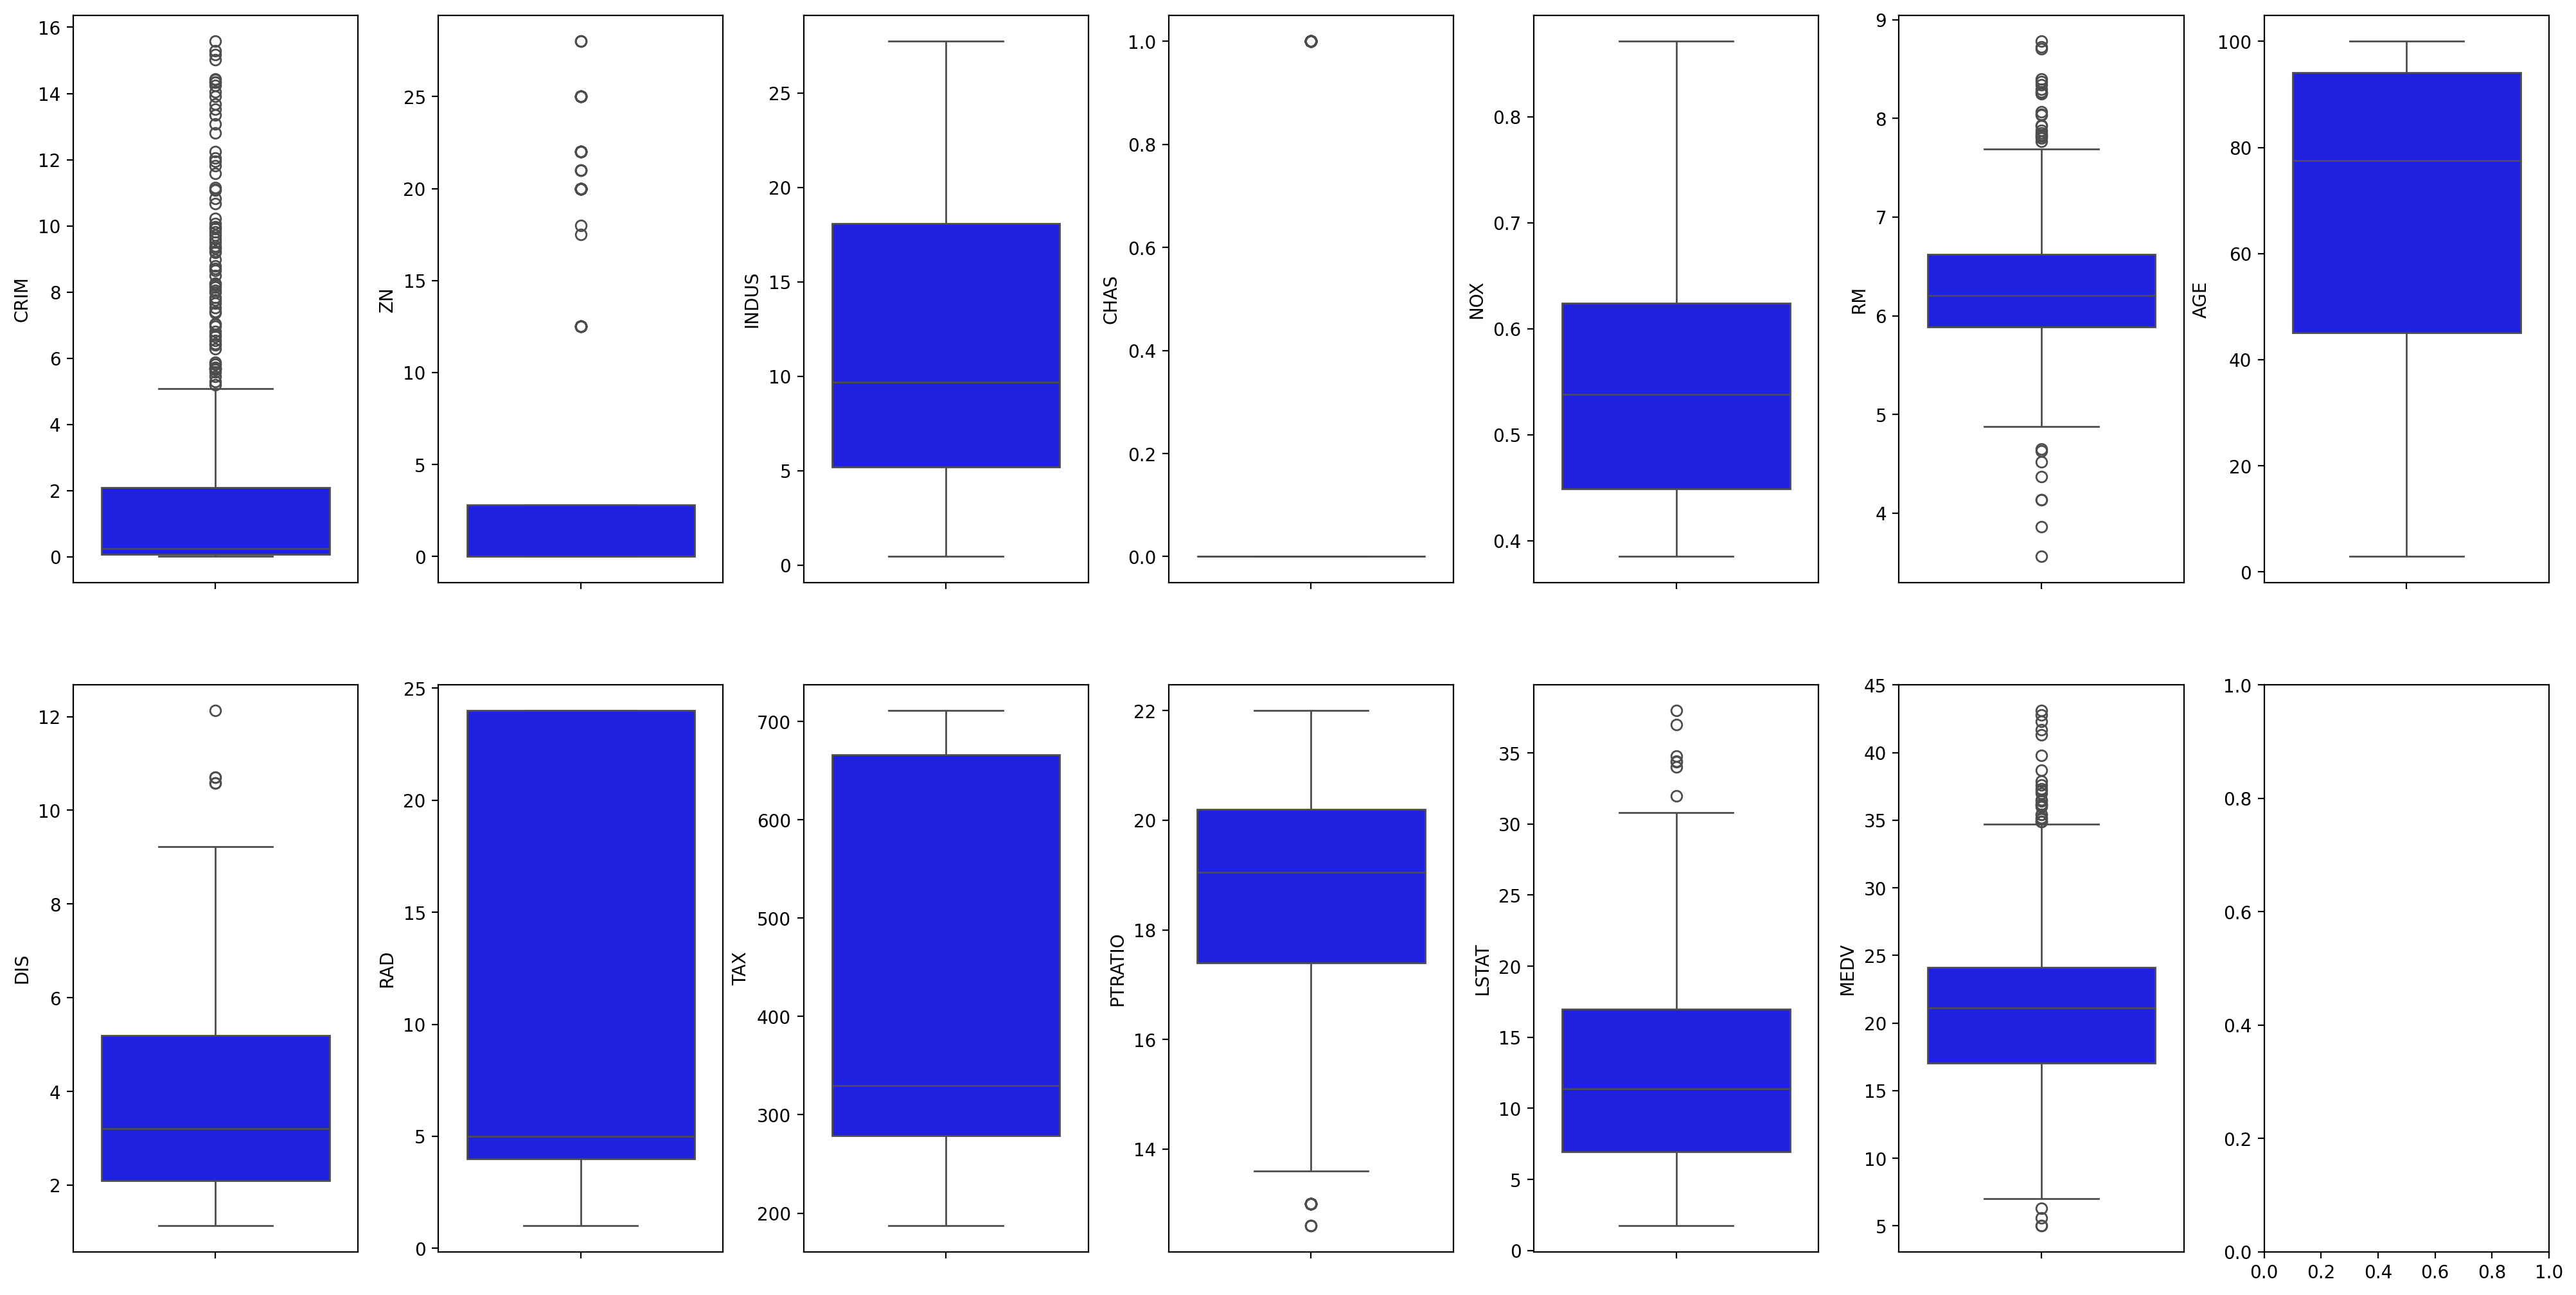

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
index = 0
axs = axs.flatten()
for k,v in data.items():
    sns.boxplot(y=k, data=data, ax=axs[index], color='blue')
    index += 1
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)


# Creating correlation matrix

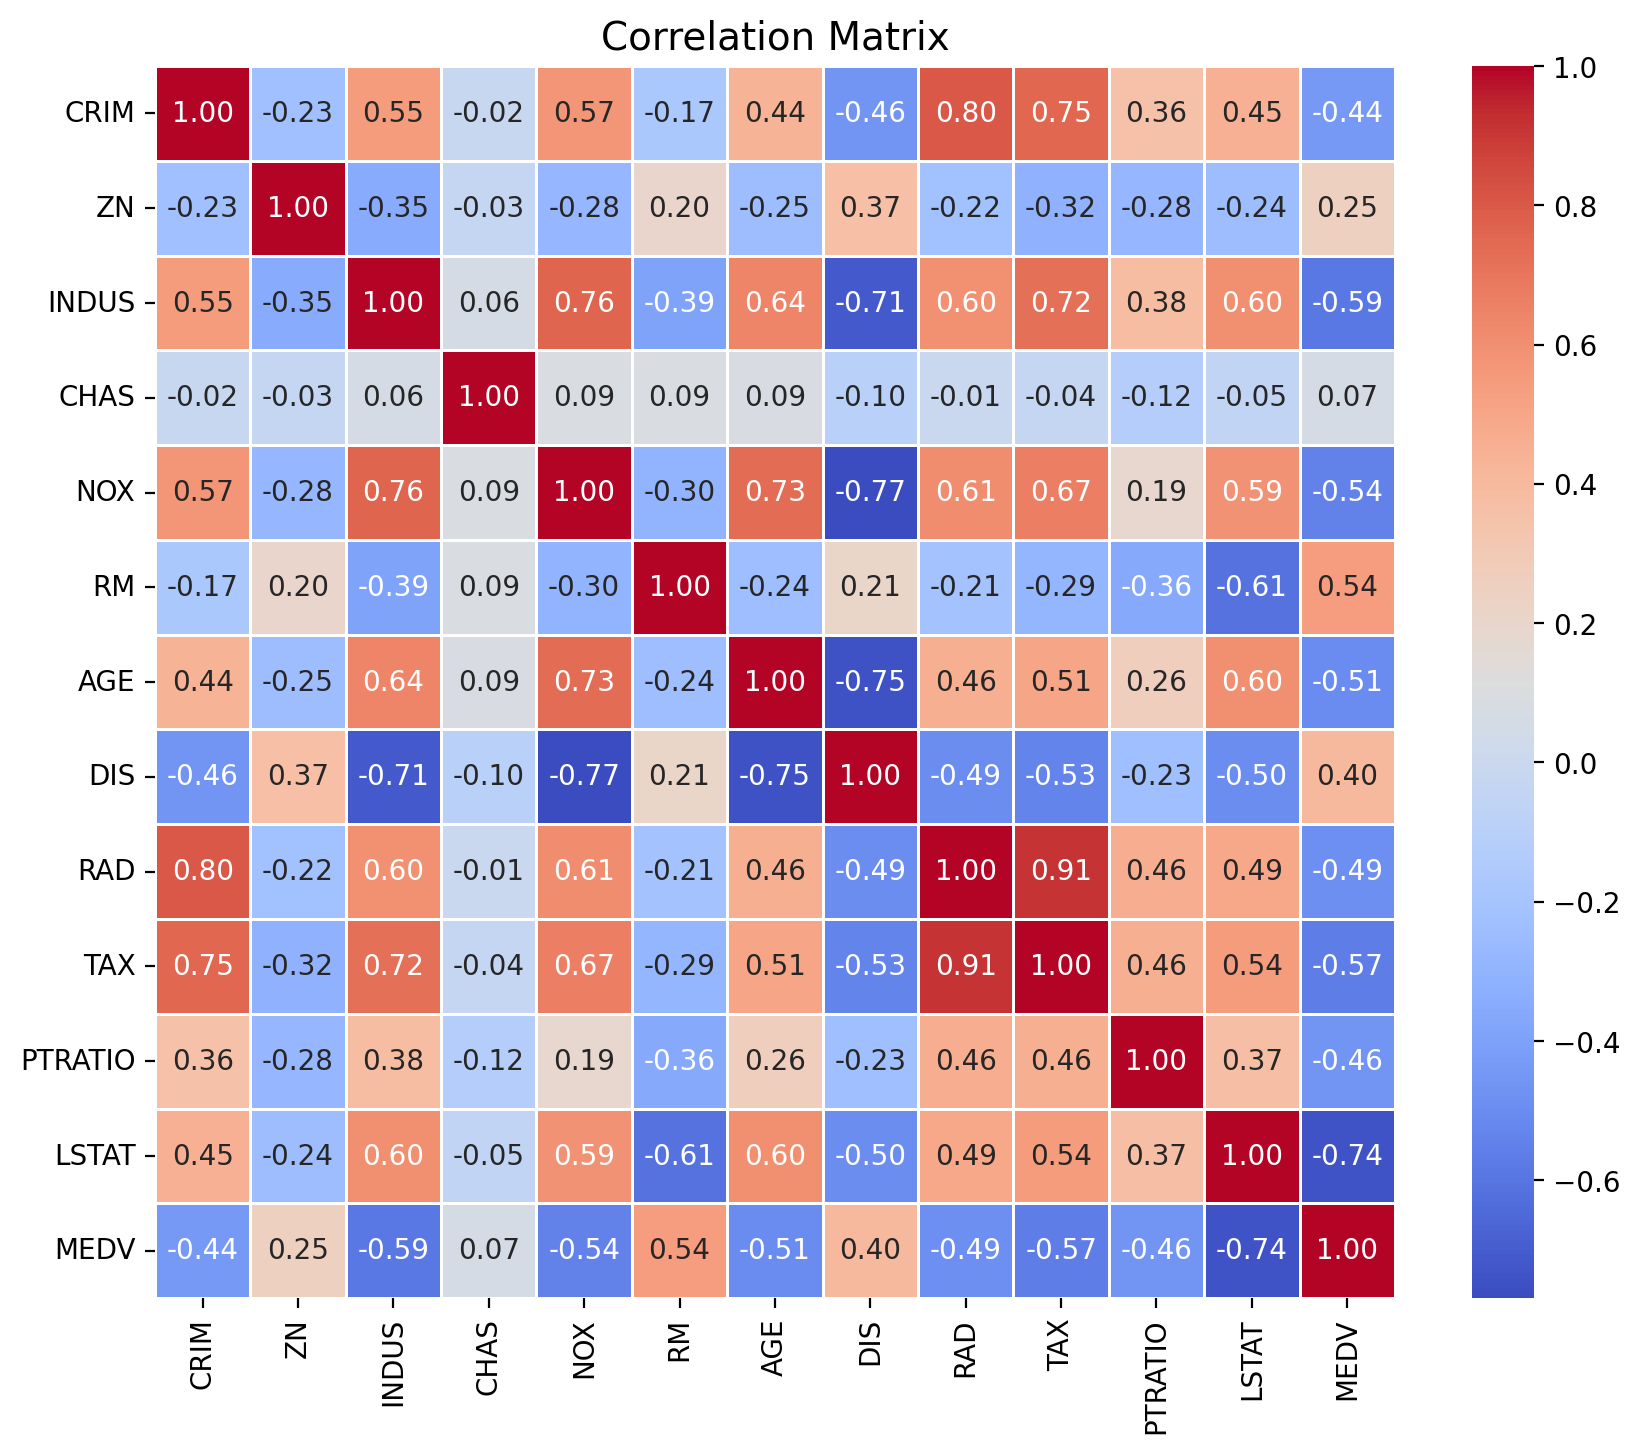

In [9]:
# Import the seaborn library
import seaborn as sns

# Compute the correlation matrix
corr_matrix = data.corr()

# Display correlation matrix
# print(corr_matrix)

# Set figure size for better readability
plt.figure(figsize=(10, 8))

# Create a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Set title
plt.title("Correlation Matrix", fontsize=14)

# Show the plot
plt.show()

# Print VIF, to see corellation measurement

In [10]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numerical predictor variables
X = data.drop(columns=['MEDV'])  # Assuming 'MEDV' is the response variable

# Add a constant for intercept (required for VIF calculation)
X = sm.add_constant(X)

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display VIF values
print(vif_data)


    Feature         VIF
0     const  542.499868
1      CRIM    2.947698
2        ZN    1.301001
3     INDUS    3.944053
4      CHAS    1.073913
5       NOX    4.379832
6        RM    1.883504
7       AGE    3.064952
8       DIS    3.489870
9       RAD    8.548879
10      TAX    8.953991
11  PTRATIO    1.672637
12    LSTAT    2.784583


# Get rid of 'RAD' variable.

In [11]:
# Delete the 'RAD' column
data = data.drop('RAD', axis=1)

# Splitting data into training set and validation set

In [12]:
# Import the necessary function
from sklearn.model_selection import train_test_split

# Set the random seed for reproducibility
np.random.seed(123)

# Define X and y
X = data.drop('MEDV', axis=1)  # Features (all columns except 'MEDV')
y = data['MEDV']  # Target variable

# Split the dataset into train and validation sets
x_train, x_valid, y_train, y_valid = train_test_split(X, y, train_size=406, random_state=123)

# Check the shapes of the train and validation sets
print(x_train.shape)
print(x_valid.shape)

(406, 11)
(100, 11)


In [13]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(123)

# Define X and y
X = data.drop('MEDV', axis=1)  # Features (all columns except 'MEDV')
y = data['MEDV']  # Target variable

# Split into training and validation sets
x_train, x_valid, y_train, y_valid = train_test_split(X, y, train_size=406, random_state=123)

# Standardize features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)

# Initialize KFold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=123)

# Perform K-means clustering within each fold
for fold, (train_idx, val_idx) in enumerate(kf.split(x_train_scaled)):
    print(f"Fold {fold+1}:")

    # Split the training data into new training and validation sets
    x_train_fold, x_val_fold = x_train_scaled[train_idx], x_train_scaled[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Apply K-means clustering on the training fold
    kmeans = KMeans(n_clusters=2, random_state=934)
    x_train_clusters = kmeans.fit_predict(x_train_fold)

    # Assign cluster labels to training fold
    x_train_df = pd.DataFrame(x_train_fold, columns=X.columns, index=y_train_fold.index)
    x_train_df['cluster'] = x_train_clusters

    # Join with target variable
    train_data = x_train_df.join(y_train_fold, how='inner')

    # Predict clusters for the validation fold
    x_val_clusters = kmeans.predict(x_val_fold)

    x_val_df = pd.DataFrame(x_val_fold, columns=X.columns, index=y_val_fold.index)
    x_val_df['cluster'] = x_val_clusters

    # Join with target variable
    val_data = x_val_df.join(y_val_fold, how='inner')

    # Compute cluster statistics
    cluster_summary = train_data.groupby('cluster').agg({'MEDV': ['mean', 'count']})
    print(cluster_summary, "\n")


Fold 1:
              MEDV      
              mean count
cluster                 
0        16.167368   123
1        23.793831   201 

Fold 2:
              MEDV      
              mean count
cluster                 
0        24.067272   192
1        16.421701   133 

Fold 3:
              MEDV      
              mean count
cluster                 
0        24.363968   195
1        15.537365   130 

Fold 4:
              MEDV      
              mean count
cluster                 
0        24.248229   192
1        16.442002   133 

Fold 5:
              MEDV      
              mean count
cluster                 
0        15.412634   121
1        24.268922   204 



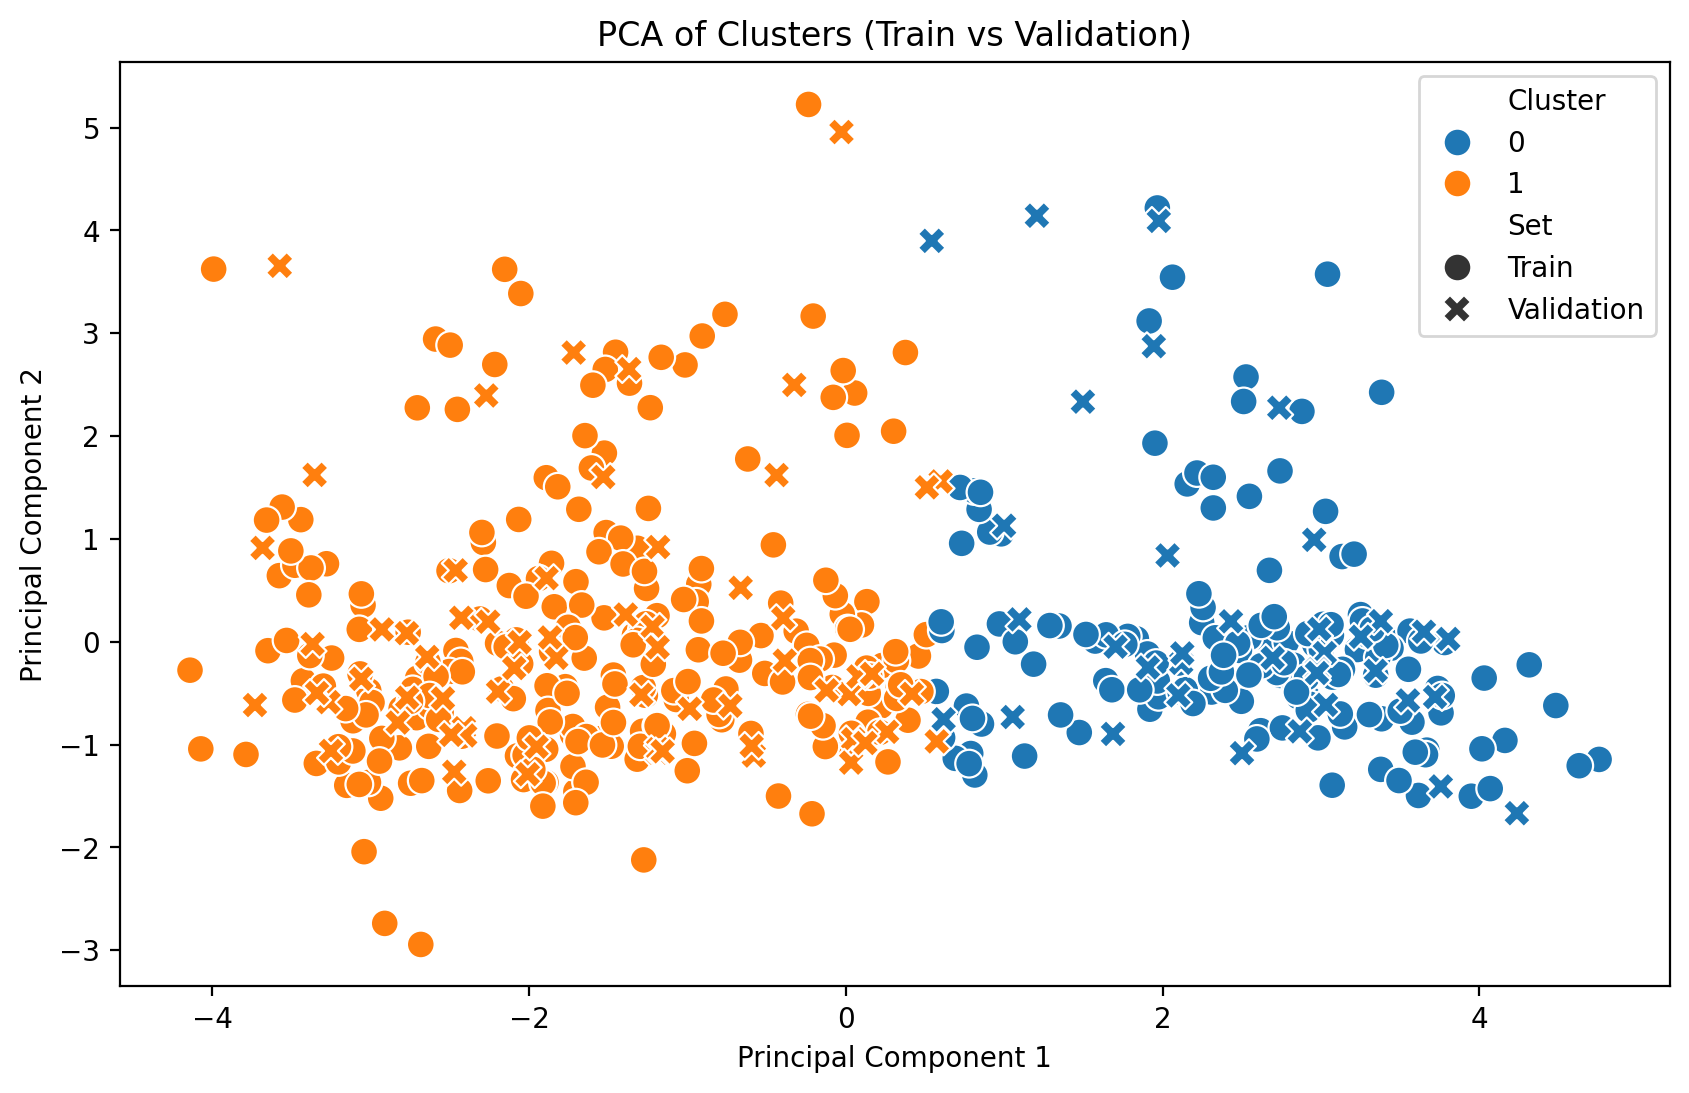

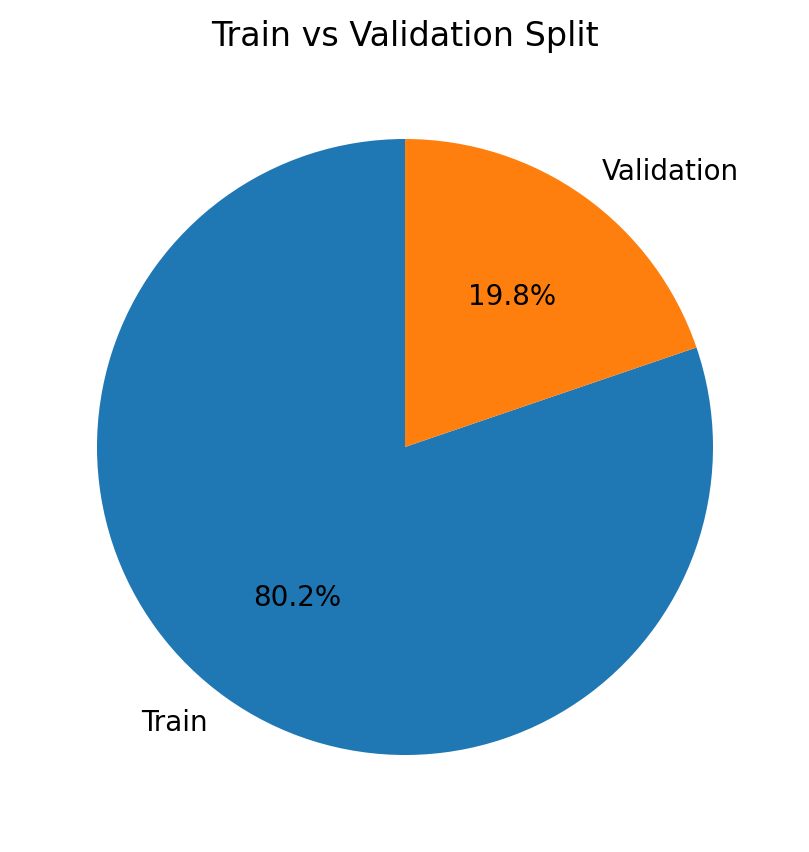

Explained Variance Ratio: [0.4783599  0.11913745]


In [14]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd

# Apply PCA to reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train_scaled)  # Fit and transform on training set
x_valid_pca = pca.transform(x_valid_scaled)  # Transform validation set using same PCA

# Create DataFrames for visualization
# Ensure x_train_clusters has the correct length
x_train_clusters = kmeans.fit_predict(x_train_scaled)  # Fit on the entire scaled training data

plot_data = pd.DataFrame({
    'PC1': x_train_pca[:, 0],
    'PC2': x_train_pca[:, 1],
    'Cluster': x_train_clusters,  # Use the correctly sized x_train_clusters
    'Set': 'Train'
})
valid_plot_data = pd.DataFrame({
    'PC1': x_valid_pca[:, 0],
    'PC2': x_valid_pca[:, 1],
    'Cluster': kmeans.predict(x_valid_scaled),  # Predict clusters for validation set
    'Set': 'Validation'
})

# Combine train and validation data
plot_data = pd.concat([plot_data, valid_plot_data])

# Plot clusters in PCA space
plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_data, x='PC1', y='PC2', hue='Cluster', style='Set', s=100)
plt.title('PCA of Clusters (Train vs Validation)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# Pie chart showing the train-validation split
split_counts = pd.Series({'Train': len(x_train), 'Validation': len(x_valid)})
plt.figure(figsize=(5, 5))
plt.pie(split_counts, labels=split_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Train vs Validation Split')
plt.show()

# Print the explained variance ratio of the first two principal components
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Ridge Regression

In [15]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize the data
#scaler = StandardScaler()
#x_train_scaled = scaler.fit_transform(x_train)
#x_valid_scaled = scaler.transform(x_valid)

# Initialize and fit Ridge regression model
ridge = Ridge(alpha=1.0)  # You can adjust alpha (regularization strength)
ridge.fit(x_train_scaled, y_train)

# Predictions
y_pred_ridge = ridge.predict(x_valid_scaled)

# Print coefficients
# Create a DataFrame for better visualization
ridge_results = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge.coef_
})

# Filter only selected features (nonzero coefficients)
ridge_results = ridge_results[ridge_results["Coefficient"] != 0]

# Print the table
print("Intercept:", ridge.intercept_)
print(ridge_results)


Intercept: 20.939171798029555
    Feature  Coefficient
0      CRIM     0.132124
1        ZN     0.202484
2     INDUS    -0.281162
3      CHAS     0.272163
4       NOX    -1.182857
5        RM     0.669807
6       AGE    -0.185644
7       DIS    -0.997210
8       TAX    -0.825120
9   PTRATIO    -0.913204
10    LSTAT    -3.397521


# Compute MSE, $R^2$, Adjusted $R^2$, AIC and BIC for Ridge Regression:

In [16]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Compute MSE for Ridge Prediction:
mse_valid_ridge = mean_squared_error(y_valid, y_pred_ridge)

# Print results
print(f"Validation MSE: {mse_valid_ridge:.4f}")

# Compute R^2 score for Ridge Regression:
r2_valid_ridge = r2_score(y_valid, y_pred_ridge)

# Print R^2
print(f"Validation R^2: {r2_valid_ridge:.4f}")


# Number of samples (n) and predictors (p)
n = len(y_valid)  # Number of observations
p = x_train.shape[1]  # Number of predictors (features)

# Compute Adjusted R^2
adjusted_r2_ridge = 1 - (1 - r2_valid_ridge) * ((n - 1) / (n - p - 1))

# Print Adjusted R^2
print(f"Validation Adjusted R^2: {adjusted_r2_ridge:.4f}")
#-----------------------------------------------------

# Compute RSS (Residual Sum of Squares)
# Predictions on the training set (scaled)
y_pred_ridge1 = ridge.predict(x_train_scaled)
rss1 = np.sum((y_train - y_pred_ridge1) ** 2)

# Compute Log-Likelihood (assuming Gaussian errors)
n1 = len(y_train)
sigma_squared1 = rss1 / n1
log_likelihood1 = -0.5 * n1 * np.log(2 * np.pi * sigma_squared1) - (rss1 / (2 * sigma_squared1))

# Count nonzero coefficients (number of selected features)
k1 = np.sum(ridge.coef_ != 0)

# Compute AIC and BIC
AIC_r = 2 * k1 - 2 * log_likelihood1
BIC_r = k1 * np.log(n1) - 2 * log_likelihood1


print("AIC:", AIC_r)
print("BIC:", BIC_r)


Validation MSE: 19.2245
Validation R^2: 0.6212
Validation Adjusted R^2: 0.5738
AIC: 2335.4234341277047
BIC: 2379.493318883324


# Lasso Regression

In [17]:
from sklearn.linear_model import Lasso

# Initialize and fit Lasso regression model
lasso = Lasso(alpha=0.1)  # Adjust alpha to control sparsity
lasso.fit(x_train_scaled, y_train)

# Predictions
y_pred_lasso = lasso.predict(x_valid_scaled)

# Print selected features (nonzero coefficients)
selected_features = x_train.columns[lasso.coef_ != 0]

# Create a DataFrame for better visualization
lasso_results = pd.DataFrame({
    "Feature": x_train.columns,
    "Coefficient": lasso.coef_
})

# Filter only selected features (nonzero coefficients)
lasso_results = lasso_results[lasso_results["Coefficient"] != 0]

print("Intercept:", lasso.intercept_)
# Print the table
print(lasso_results)


Intercept: 20.939171798029555
    Feature  Coefficient
1        ZN     0.048826
2     INDUS    -0.152843
3      CHAS     0.164212
4       NOX    -0.829846
5        RM     0.698550
7       DIS    -0.397617
8       TAX    -0.812652
9   PTRATIO    -0.850570
10    LSTAT    -3.398084


# Compute MSE, $R^2$, Adjusted $R^2$, AIC and BIC for Lasso Regression:

In [18]:
from sklearn.metrics import mean_squared_error

# Compute MSE for Lasso Prediction:
mse_valid_lasso = mean_squared_error(y_valid, y_pred_lasso)

# Print results
print(f"Validation MSE: {mse_valid_lasso:.4f}")
# -------------------------------------------------------
# Compute R^2 score for Lasso Regression:
r2_valid_lasso = r2_score(y_valid, y_pred_lasso)

# Print R^2
print(f"Validation R^2: {r2_valid_lasso:.4f}")

# -------------------------------------------------------
# Number of samples (n) and predictors (p)
n = len(y_valid)  # Number of observations
p = x_train.shape[1]  # Number of predictors (features)

# Compute Adjusted R^2
adjusted_r2_lasso = 1 - (1 - r2_valid_lasso) * ((n - 1) / (n - p - 1))

# Print Adjusted R^2
print(f"Validation Adjusted R^2: {adjusted_r2_lasso:.4f}")
#--------------------------------------------------------------
# Compute RSS (Residual Sum of Squares)
# Predictions on the training set (scaled)
y_pred_lasso1 = lasso.predict(x_train_scaled)
rss = np.sum((y_train - y_pred_lasso1) ** 2)

# Compute Log-Likelihood (assuming Gaussian errors)
n = len(y_train)
sigma_squared = rss / n
log_likelihood = -0.5 * n * np.log(2 * np.pi * sigma_squared) - (rss / (2 * sigma_squared))

# Count nonzero coefficients (number of selected features)
k = np.sum(lasso.coef_ != 0)

# Compute AIC and BIC
AIC = 2 * k - 2 * log_likelihood
BIC = k * np.log(n) - 2 * log_likelihood

# Print Results
print("AIC:", AIC)
print("BIC:", BIC)



Validation MSE: 19.6317
Validation R^2: 0.6131
Validation Adjusted R^2: 0.5648
AIC: 2334.9512089726786
BIC: 2371.008387409094


# MCMC Regression

In [20]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az
from sklearn.preprocessing import StandardScaler

# Standardizing x_train
scaler = StandardScaler()
x_train_standardized = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)

# MCMC Model (your original code)
with pm.Model() as model1:
    sigma = pm.Exponential('sigma', 1)
    alpha = pm.Normal('alpha', mu=20, sigma=3)
    beta1 = pm.Normal('beta1', mu=0, sigma=1.5)
    beta2 = pm.Normal('beta2', mu=0, sigma=1.5)
    beta3 = pm.Normal('beta3', mu=0, sigma=1.5)
    beta4 = pm.Normal('beta4', mu=0, sigma=1.5)
    beta5 = pm.Normal('beta5', mu=0, sigma=1.5)
    beta6 = pm.Normal('beta6', mu=0, sigma=1.5)
    beta7 = pm.Normal('beta7', mu=-0.05, sigma=1.5)
    beta8 = pm.Normal('beta8', mu=0, sigma=1.5)
    beta10 = pm.Normal('beta10', mu=0, sigma=1.5)
    beta11 = pm.Normal('beta11', mu=0, sigma=1.5)
    beta12 = pm.Normal('beta12', mu=0, sigma=1.5)

    _mu = (
        alpha +
        beta1 * x_train_standardized['CRIM'] +
        beta2 * x_train_standardized['ZN'] +
        beta3 * x_train_standardized['INDUS'] +
        beta4 * x_train_standardized['CHAS'] +
        beta5 * x_train_standardized['NOX'] +
        beta6 * x_train_standardized['RM'] +
        beta7 * x_train_standardized['AGE'] +
        beta8 * x_train_standardized['DIS'] +
        beta10 * x_train_standardized['TAX'] +
        beta11 * x_train_standardized['PTRATIO'] +
        beta12 * x_train_standardized['LSTAT']
    )

    mu = pm.Deterministic('mu', _mu)
    y_new = pm.Normal('MEDV', mu=mu, sigma=sigma, observed=y_train)
    _model1_samples = pm.sample(1000, tune=1000, chains=2, return_inferencedata=True)

# Extract posterior samples
posterior_samples = az.extract(_model1_samples)

# Beta coefficients list
beta_coeffs = ["beta1", "beta2", "beta3", "beta4", "beta5", "beta6",
               "beta7", "beta8", "beta10", "beta11", "beta12"]

# Stack beta samples
beta_samples = np.stack([posterior_samples[beta].values for beta in beta_coeffs], axis=-1)

# Extract alpha samples
alpha_samples_np = posterior_samples["alpha"].values.reshape(-1, 1)

# Compute predictions on TRAINING set
x_train_np = x_train_standardized.values  # Already standardized
y_pred_train_samples = alpha_samples_np + np.dot(beta_samples, x_train_np.T)
y_pred_train_mean = y_pred_train_samples.mean(axis=0)  # Posterior mean on training set

Output()

In [21]:
varnames = ['beta1', 'beta2', 'beta3', 'beta4','beta5', 'beta6', 'beta7', 'beta8', 'beta10','beta11', 'beta12', 'sigma', 'alpha']
display(pm.summary(_model1_samples))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,20.936,0.201,20.562,21.315,0.004,0.005,2293.0,1410.0,1.0
beta1,0.083,0.327,-0.492,0.725,0.007,0.007,2293.0,1486.0,1.0
beta10,-0.820,0.401,-1.534,-0.050,0.009,0.008,2147.0,1634.0,1.0
beta11,-0.897,0.266,-1.368,-0.367,0.006,0.005,2030.0,1483.0,1.0
beta12,-3.271,0.329,-3.910,-2.687,0.007,0.006,2188.0,1490.0,1.0
...,...,...,...,...,...,...,...,...,...
mu[402],15.981,0.480,15.001,16.821,0.010,0.009,2151.0,1654.0,1.0
mu[403],23.494,0.411,22.736,24.268,0.009,0.008,2181.0,1782.0,1.0
mu[404],12.290,0.513,11.269,13.152,0.010,0.009,2415.0,1662.0,1.0
mu[405],17.631,1.302,15.313,20.253,0.029,0.029,2042.0,1405.0,1.0


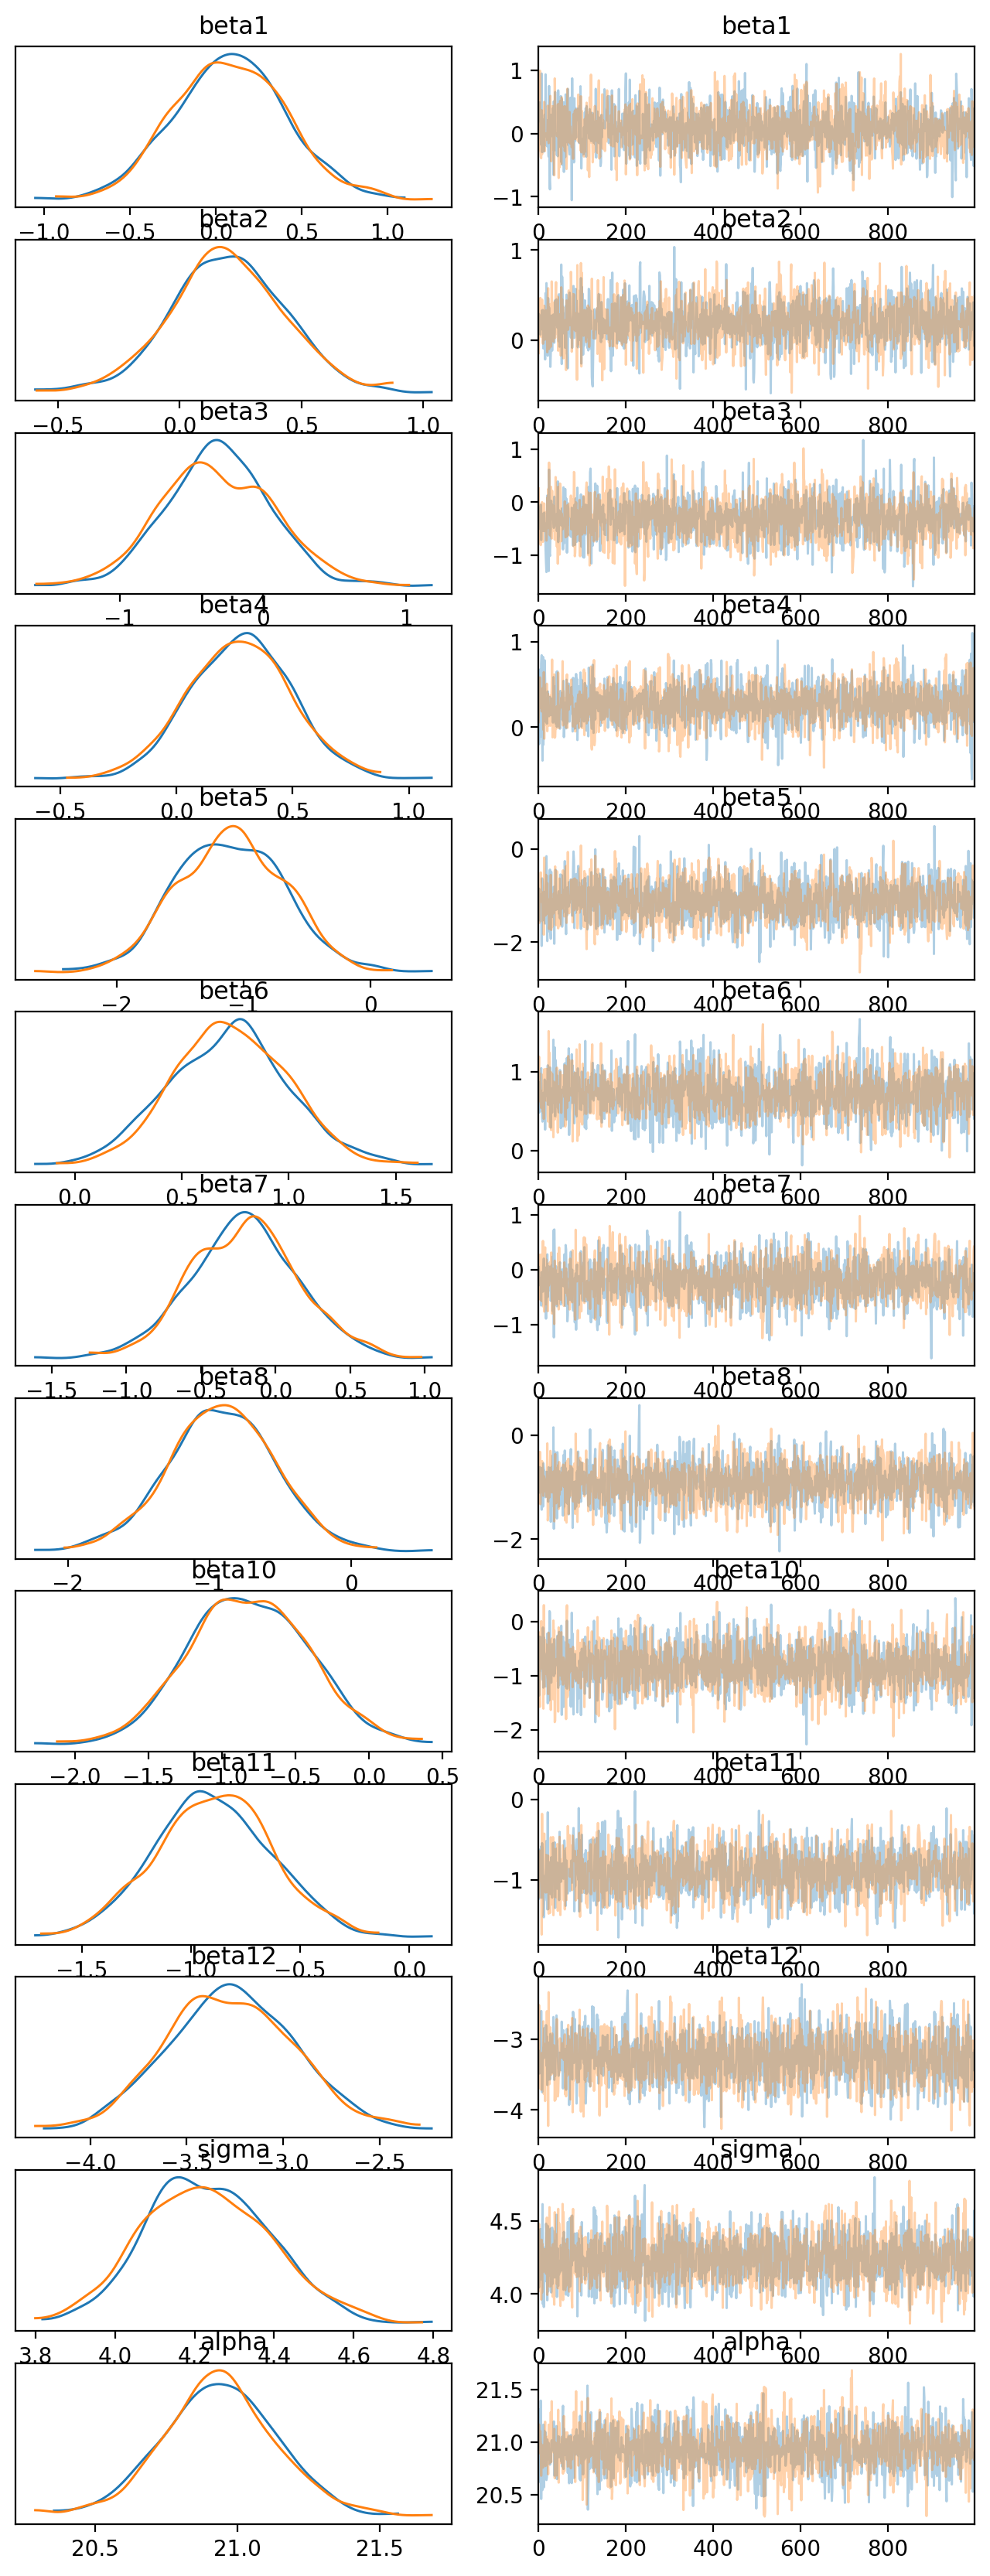

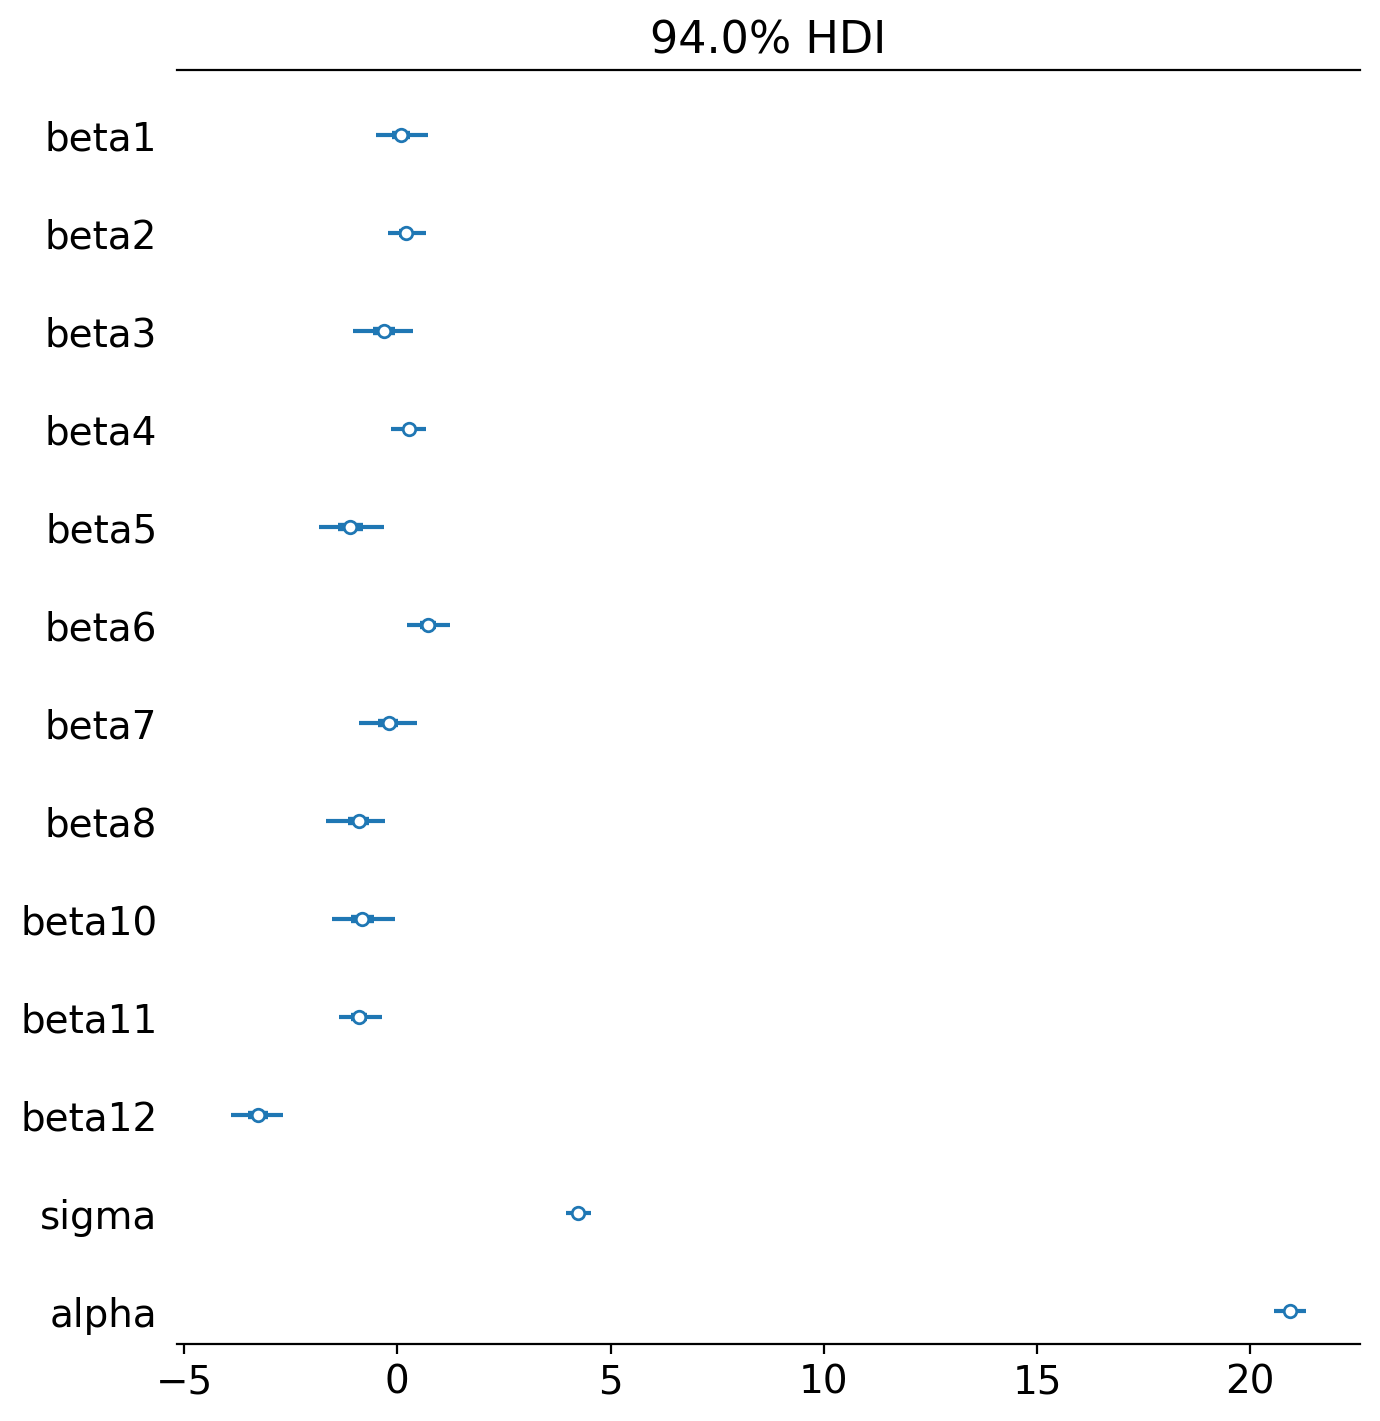

In [22]:
# Set figure size for better readability
figsize = (7, 2 + 0.4 * len(varnames))  # Dynamic height based on variable count

# Trace plot (optional, if needed)
az.plot_trace(_model1_samples, var_names=varnames, compact=False, figsize=(8, 1.6 * len(varnames)))

# Improved Forest Plot
az.plot_forest(
    _model1_samples,
    var_names=varnames,
    combined=True,
    figsize=figsize,
    hdi_prob=0.94,  # Explicitly setting HDI
    ridgeplot_alpha=0.7,  # Slight transparency for better visualization
    markersize=6  # Larger points
)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()


# Compute MSE, $R^2$, Adjusted $R^2$, AIC and BIC for MCMC Regression:

In [23]:
import numpy as np
import pandas as pd
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# Standardize x_valid using the same scaler fitted on x_train
scaler = StandardScaler()
scaler.fit(x_train)  # Already fitted on training data
x_valid_standardized = pd.DataFrame(scaler.transform(x_valid), columns=x_valid.columns)

# Extract posterior samples (already done in your code)
posterior_samples = az.extract(_model1_samples)

# Beta coefficients list
beta_coeffs = ["beta1", "beta2", "beta3", "beta4", "beta5", "beta6",
               "beta7", "beta8", "beta10", "beta11", "beta12"]

# Stack beta samples into a single NumPy array
beta_samples = np.stack([posterior_samples[beta].values for beta in beta_coeffs], axis=-1)

# Extract alpha (intercept) samples and reshape for broadcasting
alpha_samples_np = posterior_samples["alpha"].values.reshape(-1, 1)

# Convert x_valid_standardized to NumPy array
x_valid_np = x_valid_standardized.values

# Compute posterior predictive samples for validation set
y_pred_valid_samples = alpha_samples_np + np.dot(beta_samples, x_valid_np.T)

# Compute the mean prediction across posterior samples
y_pred_valid_mean = y_pred_valid_samples.mean(axis=0)

# Step 1: Compute Total Sum of Squares (TSS) for y_valid
y_valid_mean = np.mean(y_valid)
tss_valid = np.sum((y_valid - y_valid_mean) ** 2)

# Step 2: Compute Residual Sum of Squares (RSS) for y_valid
rss_valid = np.sum((y_valid - y_pred_valid_mean) ** 2)

# Step 3: Compute R² for validation set
r2_valid = 1 - (rss_valid / tss_valid)

# Step 4: (Optional) Compute MSE for consistency check
mse_valid_mcmc = mean_squared_error(y_valid, y_pred_valid_mean)

# Calculating Adjusted R^2

# Calculate number of observations (n) and number of predictors (k)
n_mcmc = len(y_train)  # Number of data points in the training set
p_mcmc = x_train.shape[1]  # Number of predictors (features)

# Calculate Adjusted R^2
adjusted_r2_valid_mcmc = 1 - ((1 - r2_valid) * (n_mcmc - 1) / (n_mcmc - p_mcmc - 1))

# Print results
print(f"Validation TSS: {tss_valid:.4f}")
print(f"Validation RSS: {rss_valid:.4f}")
print(f"Validation R^2: {r2_valid:.4f}")
print(f"Validation adjusted R^2: {adjusted_r2_valid_mcmc:.4f}")
print(f"Validation MSE: {mse_valid_mcmc:.4f}")

# --------------------------------- AIC & BIC -------------------
# Define standard deviation (sigma)
sigma = np.std(y_valid - y_pred_lasso)  # Estimate if unknown

# Compute log-likelihood for each data point
log_likelihood_manual = stats.norm.logpdf(y_valid, loc=y_pred_lasso, scale=sigma)

# Sum log-likelihood across all data points
total_log_likelihood = np.sum(log_likelihood_manual)

#print(f"Log-Likelihood: {total_log_likelihood:.4f}")

# Number of estimated parameters (excluding auxiliary parameters like sigma)
k = x_train.shape[1]  # Number of predictors

# Number of observations
n = len(y_train)

# Compute AIC and BIC using manually computed log-likelihood
AIC = 2 * k - 2 * total_log_likelihood
BIC = k * np.log(n) - 2 * total_log_likelihood

# Print results
print("AIC:", AIC)
print("BIC:", BIC)

Validation TSS: 5074.5639
Validation RSS: 1913.4825
Validation R^2: 0.6229
Validation adjusted R^2: 0.6124
Validation MSE: 19.1348
AIC: 603.5048789834391
BIC: 647.5747637390582


# Result Analysis:

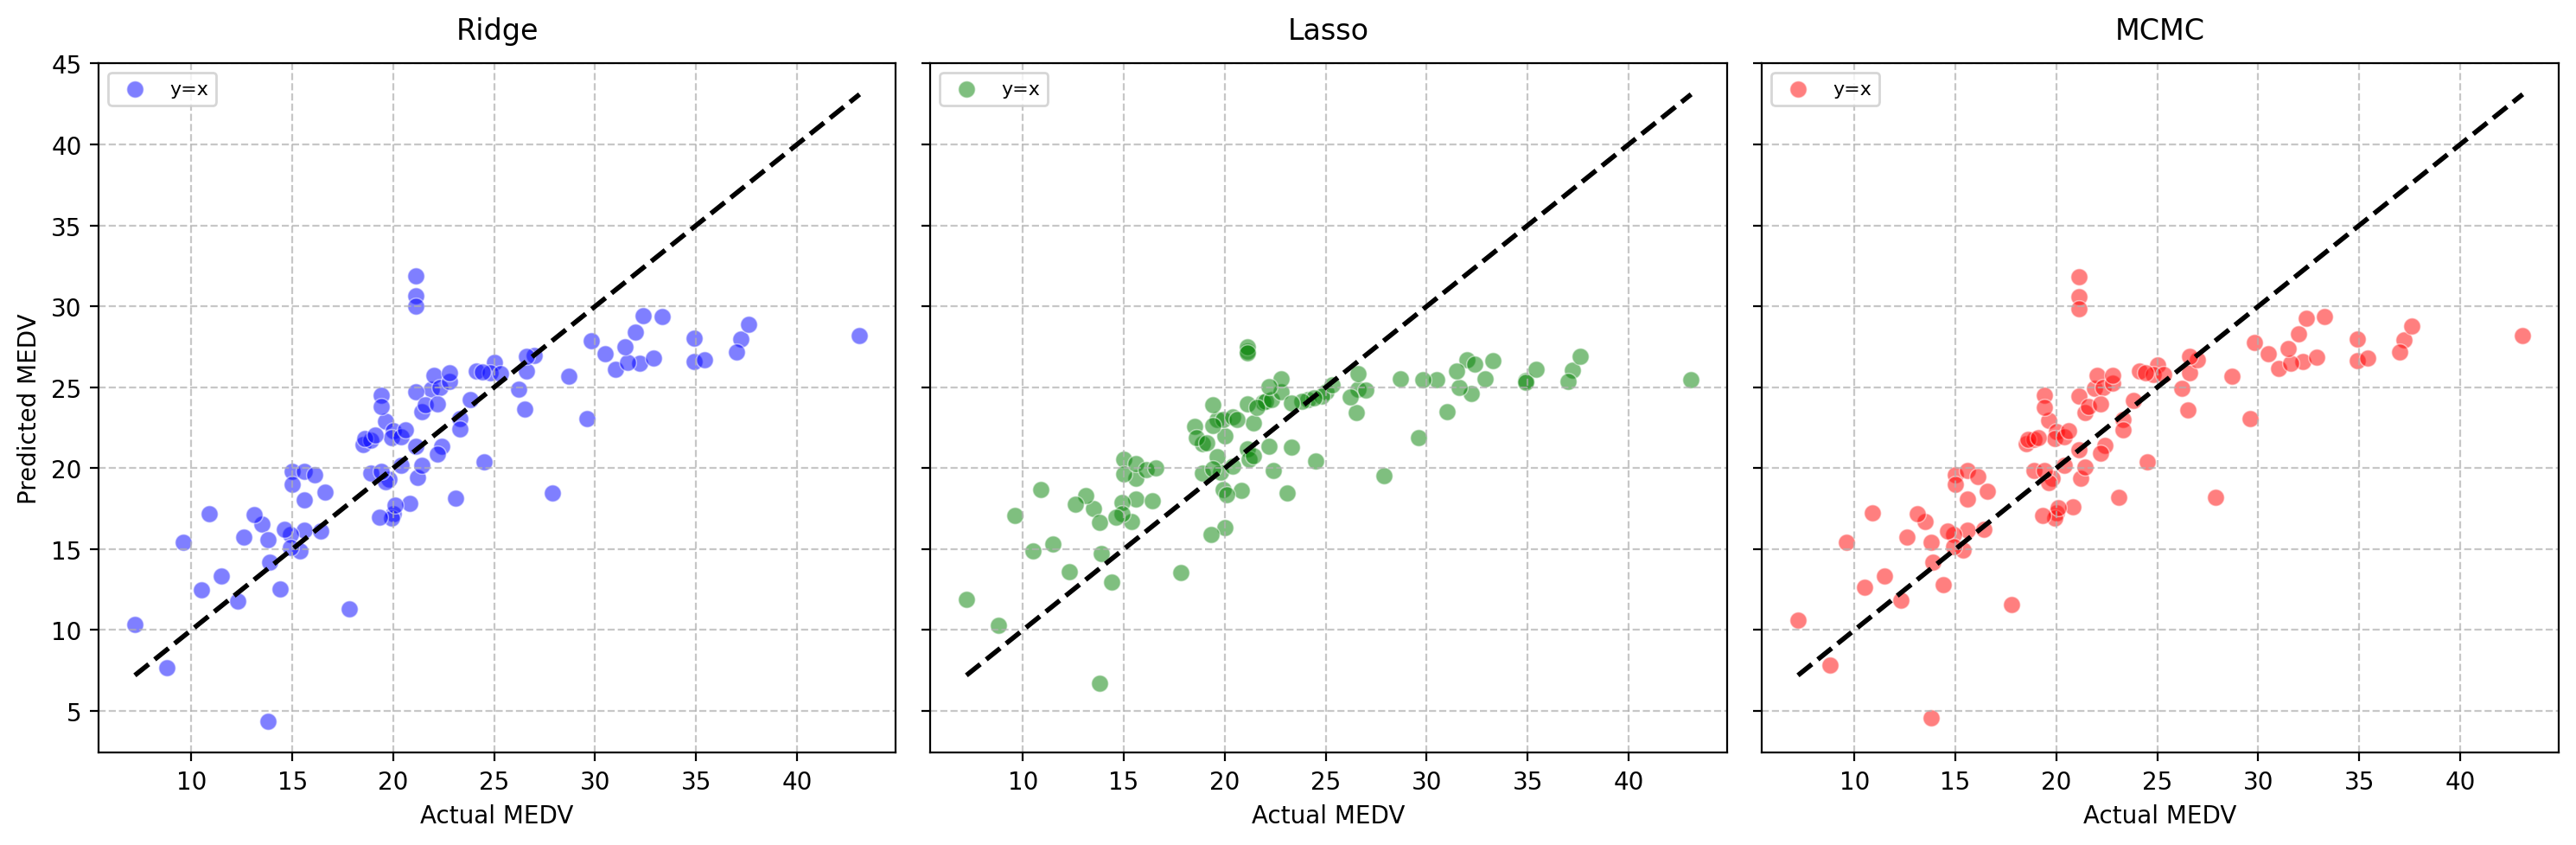

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)

# 1. Ridge Predictions
ridge = Ridge(alpha=1.0)  # Adjust alpha as needed
ridge.fit(x_train_scaled, y_train)
y_pred_ridge = ridge.predict(x_valid_scaled)

# 2. Lasso Predictions
lasso = Lasso(alpha=1.0)  # Adjust alpha as needed
lasso.fit(x_train_scaled, y_train)
y_pred_lasso = lasso.predict(x_valid_scaled)

# 3. MCMC Predictions
posterior_samples = az.extract(_model1_samples)
beta_coeffs = ["beta1", "beta2", "beta3", "beta4", "beta5", "beta6",
               "beta7", "beta8", "beta10", "beta11", "beta12"]
beta_samples = np.stack([posterior_samples[beta].values for beta in beta_coeffs], axis=-1)
alpha_samples_np = posterior_samples["alpha"].values.reshape(-1, 1)
x_valid_standardized = scaler.transform(x_valid)  # Use the same scaler as Ridge/Lasso
x_valid_np = x_valid_standardized
y_pred_samples = alpha_samples_np + np.dot(beta_samples, x_valid_np.T)
y_pred_mcmc = y_pred_samples.mean(axis=0)  # Posterior mean

# Create a figure with 3 subplots (1 row, 3 columns)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

# Plot 1: Ridge
sns.scatterplot(x=y_valid, y=y_pred_ridge, color='blue', alpha=0.5, s=50, ax=ax1)
ax1.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()],
         'k--', lw=2, label='y=x')  # Black dashed y=x line
ax1.set_title("Ridge", fontsize=12, pad=10)
ax1.set_xlabel("Actual MEDV", fontsize=10)
ax1.set_ylabel("Predicted MEDV", fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(['y=x'], loc='best', fontsize=8)

# Plot 2: Lasso
sns.scatterplot(x=y_valid, y=y_pred_lasso, color='green', alpha=0.5, s=50, ax=ax2)
ax2.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()],
         'k--', lw=2, label='y=x')
ax2.set_title("Lasso", fontsize=12, pad=10)
ax2.set_xlabel("Actual MEDV", fontsize=10)
ax2.set_ylabel("Predicted MEDV", fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(['y=x'], loc='best', fontsize=8)

# Plot 3: MCMC
sns.scatterplot(x=y_valid, y=y_pred_mcmc, color='red', alpha=0.5, s=50, ax=ax3)
ax3.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()],
         'k--', lw=2, label='y=x')
ax3.set_title("MCMC", fontsize=12, pad=10)
ax3.set_xlabel("Actual MEDV", fontsize=10)
ax3.set_ylabel("Predicted MEDV", fontsize=10)
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.legend(['y=x'], loc='best', fontsize=8)

# Add a super title for the entire figure
#fig.suptitle("Actual vs. Predicted MEDV for Ridge, Lasso, and MCMC", fontsize=14, fontweight='bold', y=1.05)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

# Result with mean imputation
\begin{array}{|c|c|c|c|}
\hline
 & \textbf{Ridge Regression} & \textbf{Lasso Regression} & \textbf{MCMC Method} \\
\hline
MSE & 19.318 & 19.653 & 19.145 \\
R^{2} & 0.619 & 0.613 & 0.623 \\
\text{Adjusted } R^{2} & 0.572 & 0.564 & 0.612 \\
AIC & 2333.83 & 2333.55 & 603.615\\
BIC & 2377.91 & 2369.61 & 647.685 \\
\hline
\end{array}


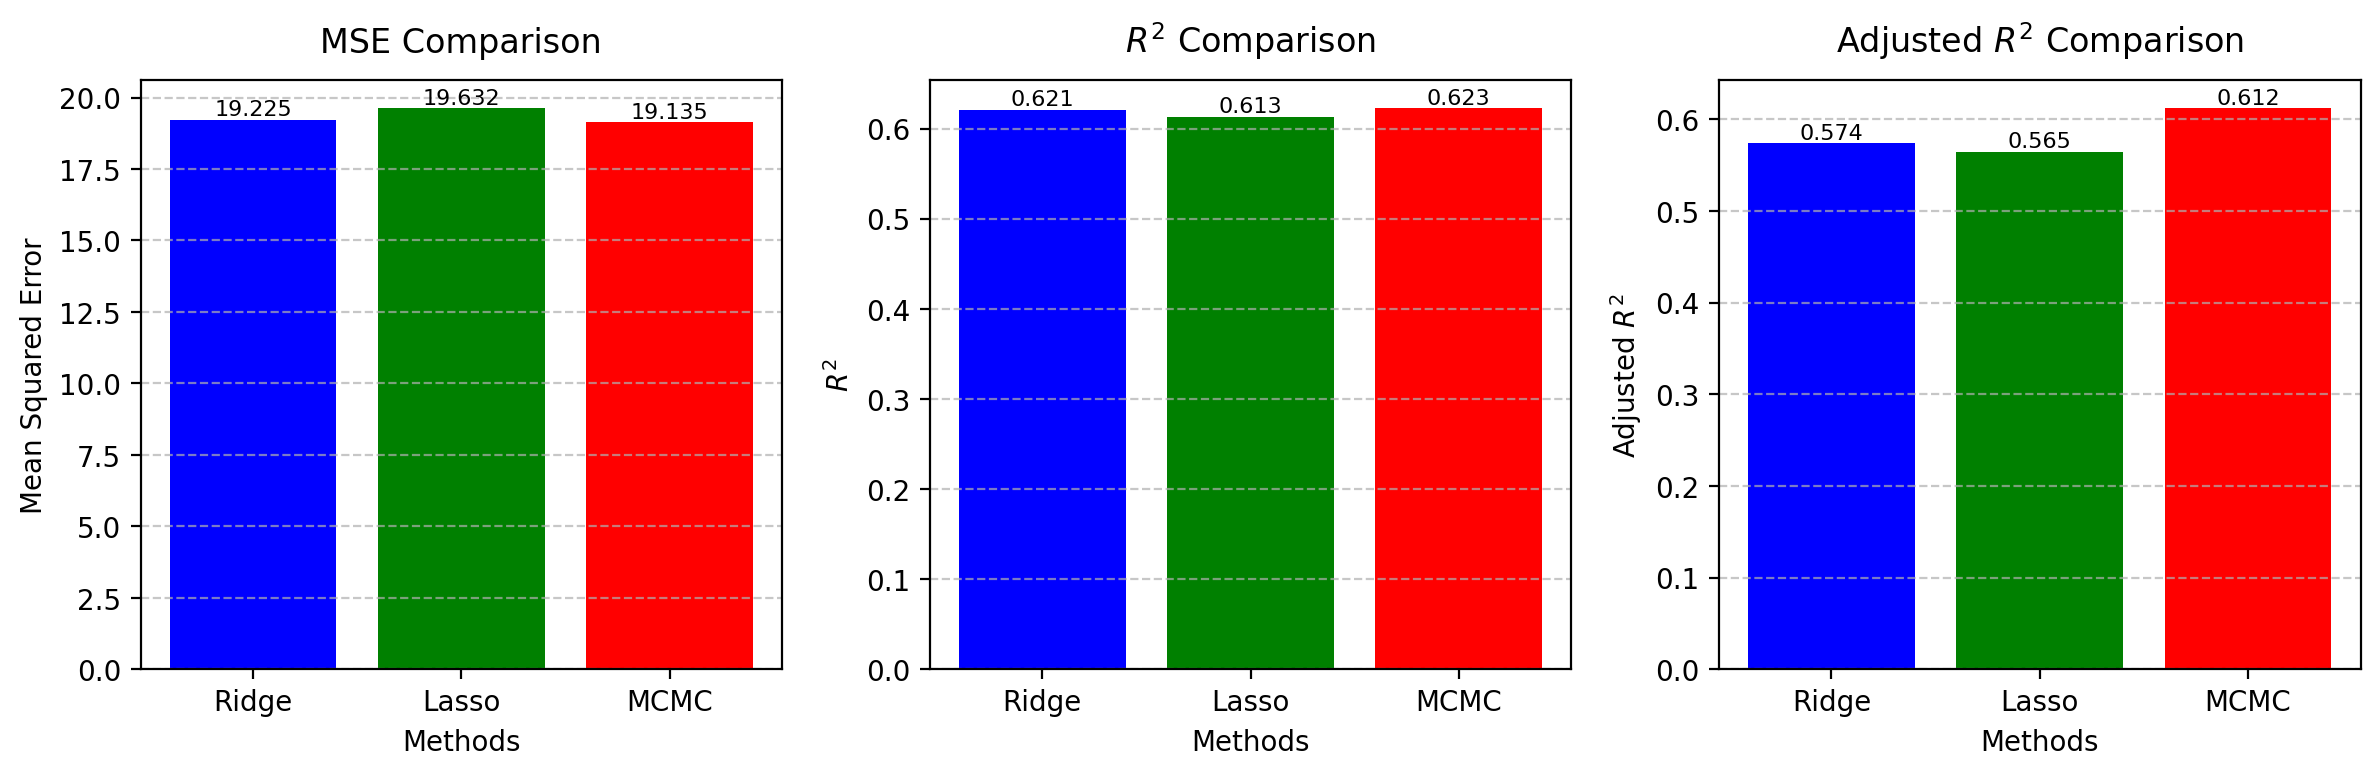

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Data for plotting
methods = ['Ridge', 'Lasso', 'MCMC']
mse_values = [mse_valid_ridge, mse_valid_lasso, mse_valid_mcmc]
r2_values = [r2_valid_ridge, r2_valid_lasso, r2_valid]
adj_r2_values = [adjusted_r2_ridge, adjusted_r2_lasso, adjusted_r2_valid_mcmc]

# Create a figure with 3 subplots side by side
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

# Colors for consistency
colors = ['blue', 'green', 'red']

# MSE Bar Plot (Subplot 1)
bars1 = ax1.bar(methods, mse_values, color=colors)
ax1.set_title('MSE Comparison', fontsize=12, pad=10)
ax1.set_xlabel('Methods', fontsize=10)
ax1.set_ylabel('Mean Squared Error', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# R² Bar Plot (Subplot 2)
bars2 = ax2.bar(methods, r2_values, color=colors)
ax2.set_title('$R^2$ Comparison', fontsize=12, pad=10)
ax2.set_xlabel('Methods', fontsize=10)
ax2.set_ylabel('$R^2$', fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Adjusted R² Bar Plot (Subplot 3)
bars3 = ax3.bar(methods, adj_r2_values, color=colors)
ax3.set_title('Adjusted $R^2$ Comparison', fontsize=12, pad=10)
ax3.set_xlabel('Methods', fontsize=10)
ax3.set_ylabel('Adjusted $R^2$', fontsize=10)
ax3.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

In [26]:
# Assuming x_train and y_train are DataFrames/Series
data_train = x_train.copy()
data_train['MEDV'] = y_train
correlation_matrix = data_train.corr()
print("Correlation with CRIM:")
#print(correlation_matrix['CRIM'])
print(correlation_matrix['MEDV'])

Correlation with CRIM:
CRIM      -0.447998
ZN         0.251961
INDUS     -0.577202
CHAS       0.076729
NOX       -0.545182
RM         0.533086
AGE       -0.489483
DIS        0.400789
TAX       -0.578950
PTRATIO   -0.438968
LSTAT     -0.747398
MEDV       1.000000
Name: MEDV, dtype: float64
